In [35]:
import numpy as np
from scipy import stats
import pandas as pd

from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

In [36]:
path = "ai4i2020.csv"
df = pd.read_csv(path)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [9]:
df.iloc[10]

UDI                            11
Product ID                 H29424
Type                            H
Air temperature [K]         298.4
Process temperature [K]     308.9
Rotational speed [rpm]       1782
Torque [Nm]                  23.9
Tool wear [min]                24
Machine failure                 0
TWF                             0
HDF                             0
PWF                             0
OSF                             0
RNF                             0
Name: 10, dtype: object

H등급 제품 H29424가 공기 온도 298.4K, 공정 온도 약 308.9K에서 분당 1,782회로 회전하고 있다. 토크는 23.9Nm이고 공구 누적 사용시간은 24분이다. 현재 기계 고장은 발생하지 않았으며 모든 세부 고장 유형도 0이다.

In [17]:
print(df["Type"].value_counts())

print(df["Machine failure"].value_counts())

print(df["TWF"].value_counts())

print(df["HDF"].value_counts())

print(df["PWF"].value_counts())

print(df["OSF"].value_counts())

print(df["RNF"].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64
Machine failure
0    9661
1     339
Name: count, dtype: int64
TWF
0    9954
1      46
Name: count, dtype: int64
HDF
0    9885
1     115
Name: count, dtype: int64
PWF
0    9905
1      95
Name: count, dtype: int64
OSF
0    9902
1      98
Name: count, dtype: int64
RNF
0    9981
1      19
Name: count, dtype: int64


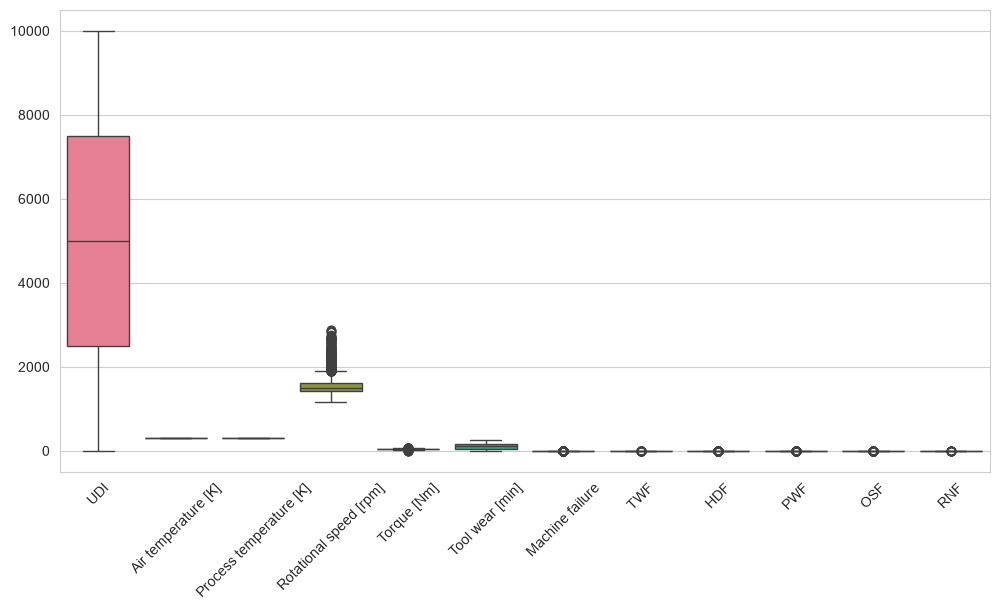

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(df)
plt.xticks(rotation=45)
plt.show()

In [37]:
exclude_cols = [
    "UDI",                 # 단순 식별번호
    "Machine failure",     # 전체 고장 여부
    "TWF",                 # 공구 마모 고장
    "HDF",                 # 열 방출 고장
    "PWF",                 # 전력 고장
    "OSF",                 # 과부하 고장
    "RNF"                  # 무작위 고장
]

# 3. 제외할 컬럼을 제거하고 숫자형 데이터만 선택
numeric_df = (
    df.drop(columns=exclude_cols)
      .select_dtypes(include="number")
)

print("스케일링 대상 컬럼:")
print(numeric_df.columns.tolist())

스케일링 대상 컬럼:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [38]:
# 4. 숫자형 데이터 표준화
scaler = StandardScaler()

scaled_array = scaler.fit_transform(numeric_df)

# 넘파이 배열을 다시 데이터프레임으로 변환
df_scaled = pd.DataFrame(
    scaled_array,
    columns=numeric_df.columns,
    index=numeric_df.index
)

df_scaled.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,-0.952389,-0.947360,0.068185,0.282200,-1.695984
1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852
2,-0.952389,-1.014761,-0.227450,0.944290,-1.617430
3,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009
4,-0.902393,-0.879959,-0.729472,0.001313,-1.554588


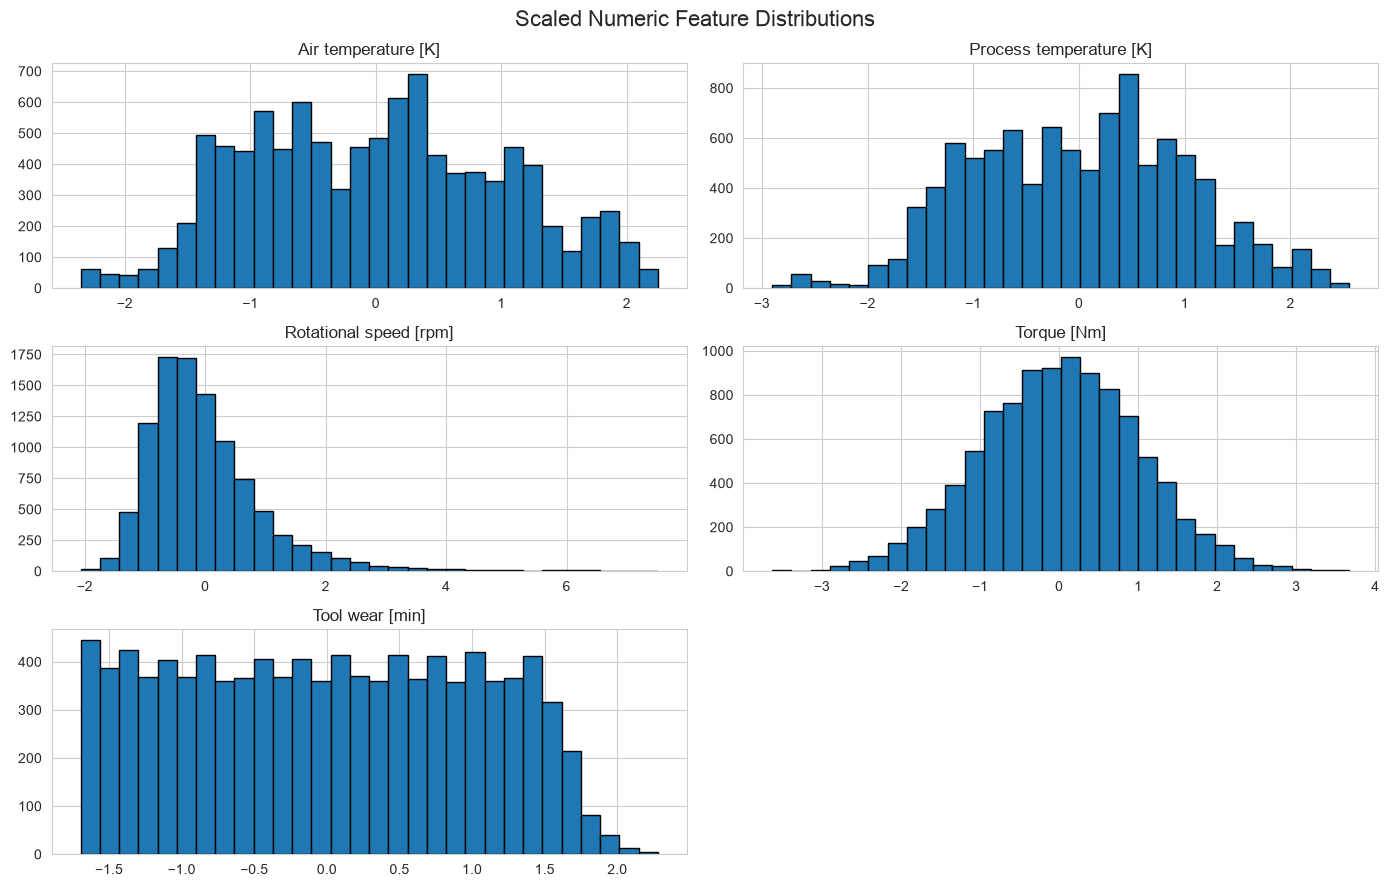

In [39]:
df_scaled.hist(
    bins=30,
    figsize=(14, 9),
    edgecolor="black"
)

plt.suptitle("Scaled Numeric Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

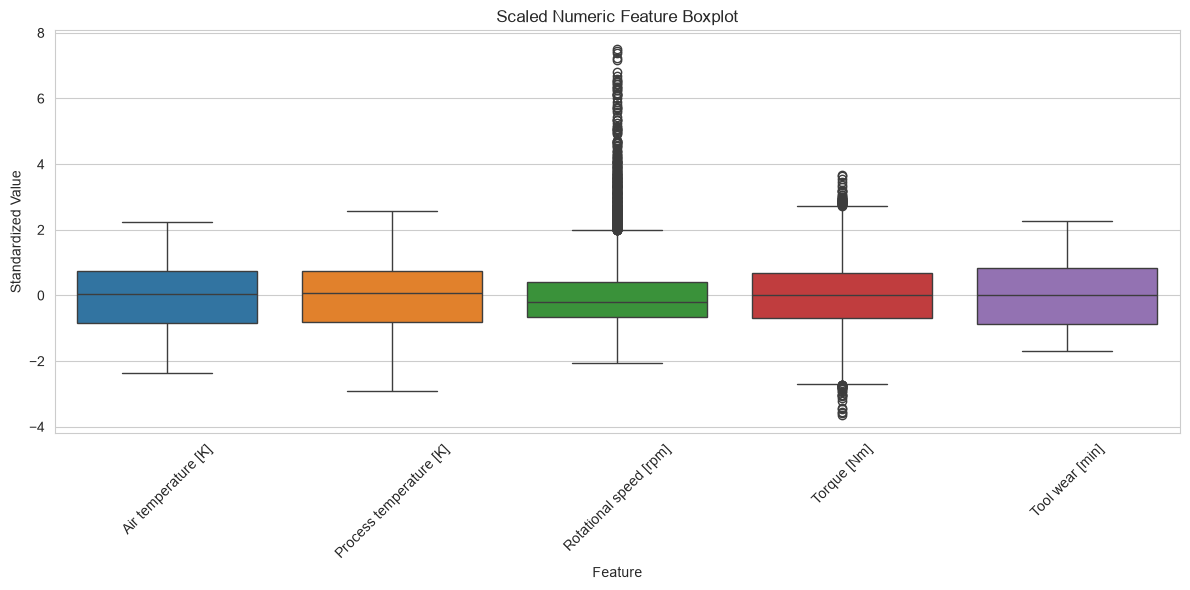

In [40]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_scaled)

plt.title("Scaled Numeric Feature Boxplot")
plt.xlabel("Feature")
plt.ylabel("Standardized Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [46]:
temp_df = df[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Machine failure"
    ]
].copy()

temp_df["Temperature difference [K]"] = (
    temp_df["Process temperature [K]"]
    - temp_df["Air temperature [K]"]
)

temp_df.head()

,Air temperature [K],Process temperature [K],Machine failure,Temperature difference [K]
0,298.1,308.6,0,10.5
1,298.2,308.7,0,10.5
2,298.1,308.5,0,10.4
3,298.2,308.6,0,10.4
4,298.2,308.7,0,10.5


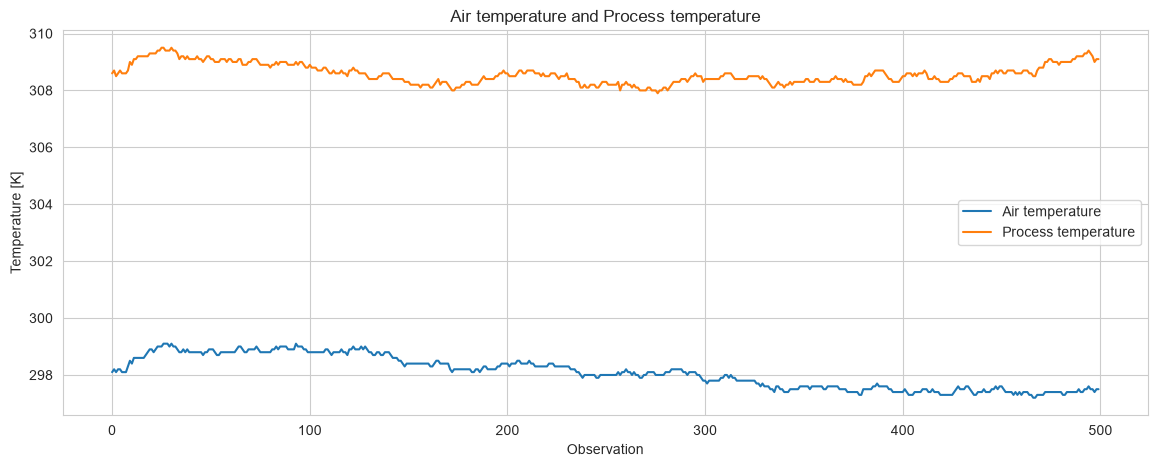

In [47]:
sample = temp_df.iloc[:500]

plt.figure(figsize=(14, 5))

plt.plot(
    sample.index,
    sample["Air temperature [K]"],
    label="Air temperature"
)

plt.plot(
    sample.index,
    sample["Process temperature [K]"],
    label="Process temperature"
)

plt.title("Air temperature and Process temperature")
plt.xlabel("Observation")
plt.ylabel("Temperature [K]")
plt.legend()
plt.show()

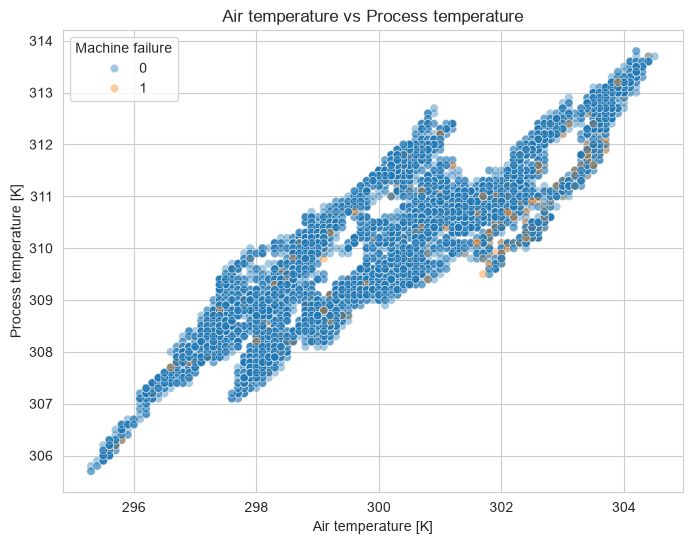

In [48]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=temp_df,
    x="Air temperature [K]",
    y="Process temperature [K]",
    hue="Machine failure",
    alpha=0.4
)

plt.title("Air temperature vs Process temperature")
plt.xlabel("Air temperature [K]")
plt.ylabel("Process temperature [K]")
plt.show()

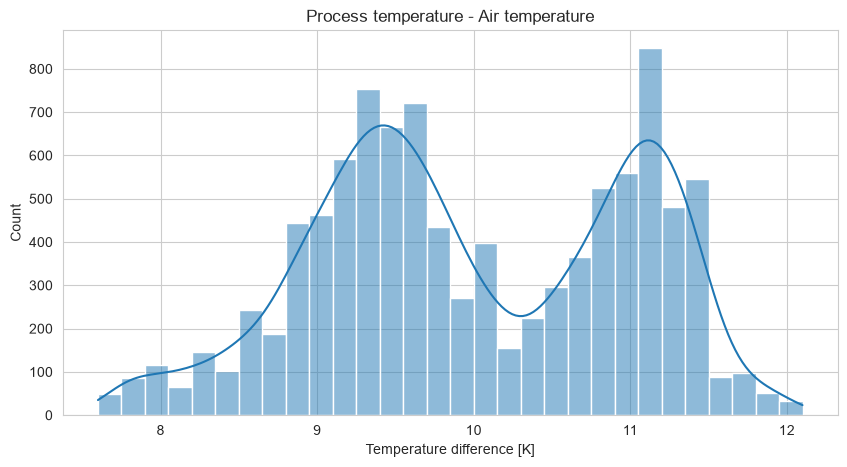

In [49]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=temp_df,
    x="Temperature difference [K]",
    bins=30,
    kde=True
)

plt.title("Process temperature - Air temperature")
plt.xlabel("Temperature difference [K]")
plt.ylabel("Count")
plt.show()

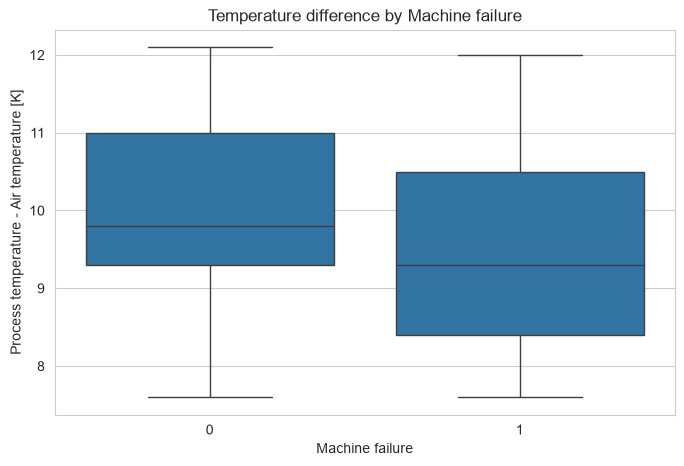

In [50]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=temp_df,
    x="Machine failure",
    y="Temperature difference [K]"
)

plt.title("Temperature difference by Machine failure")
plt.xlabel("Machine failure")
plt.ylabel("Process temperature - Air temperature [K]")
plt.show()

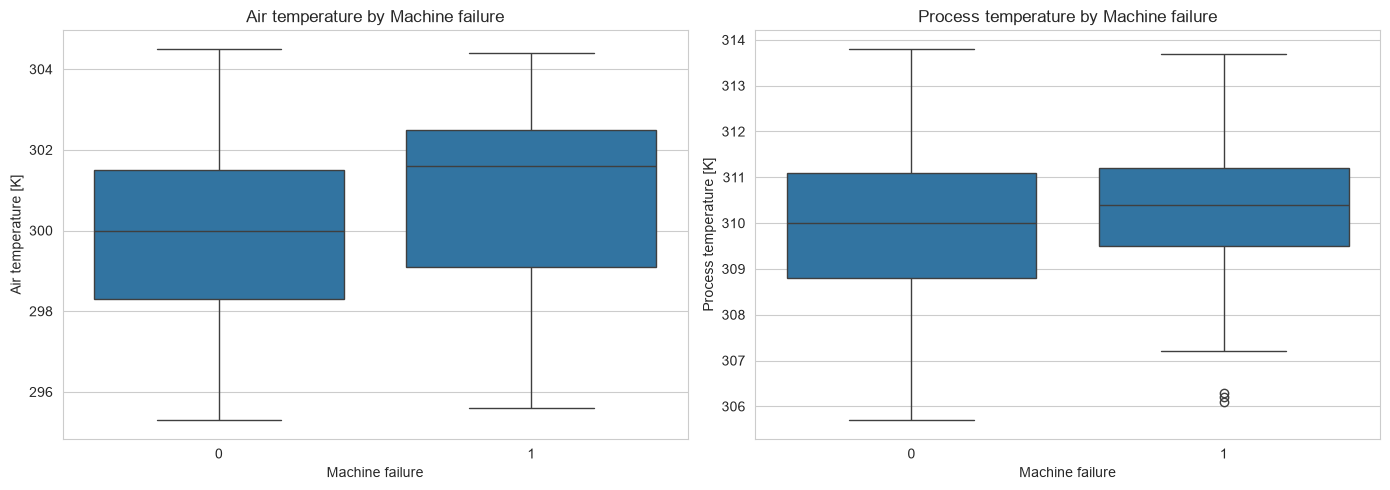

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=temp_df,
    x="Machine failure",
    y="Air temperature [K]",
    ax=axes[0]
)

axes[0].set_title("Air temperature by Machine failure")

sns.boxplot(
    data=temp_df,
    x="Machine failure",
    y="Process temperature [K]",
    ax=axes[1]
)

axes[1].set_title("Process temperature by Machine failure")

plt.tight_layout()
plt.show()

In [52]:
temp_df["Air temperature bin"] = pd.qcut(
    temp_df["Air temperature [K]"],
    q=10,
    duplicates="drop"
)

temp_df["Process temperature bin"] = pd.qcut(
    temp_df["Process temperature [K]"],
    q=10,
    duplicates="drop"
)

air_failure_rate = (
    temp_df.groupby(
        "Air temperature bin",
        observed=True
    )["Machine failure"]
    .mean()
    .reset_index()
)

process_failure_rate = (
    temp_df.groupby(
        "Process temperature bin",
        observed=True
    )["Machine failure"]
    .mean()
    .reset_index()
)

air_failure_rate["Air temperature bin"] = (
    air_failure_rate["Air temperature bin"].astype(str)
)

process_failure_rate["Process temperature bin"] = (
    process_failure_rate["Process temperature bin"].astype(str)
)

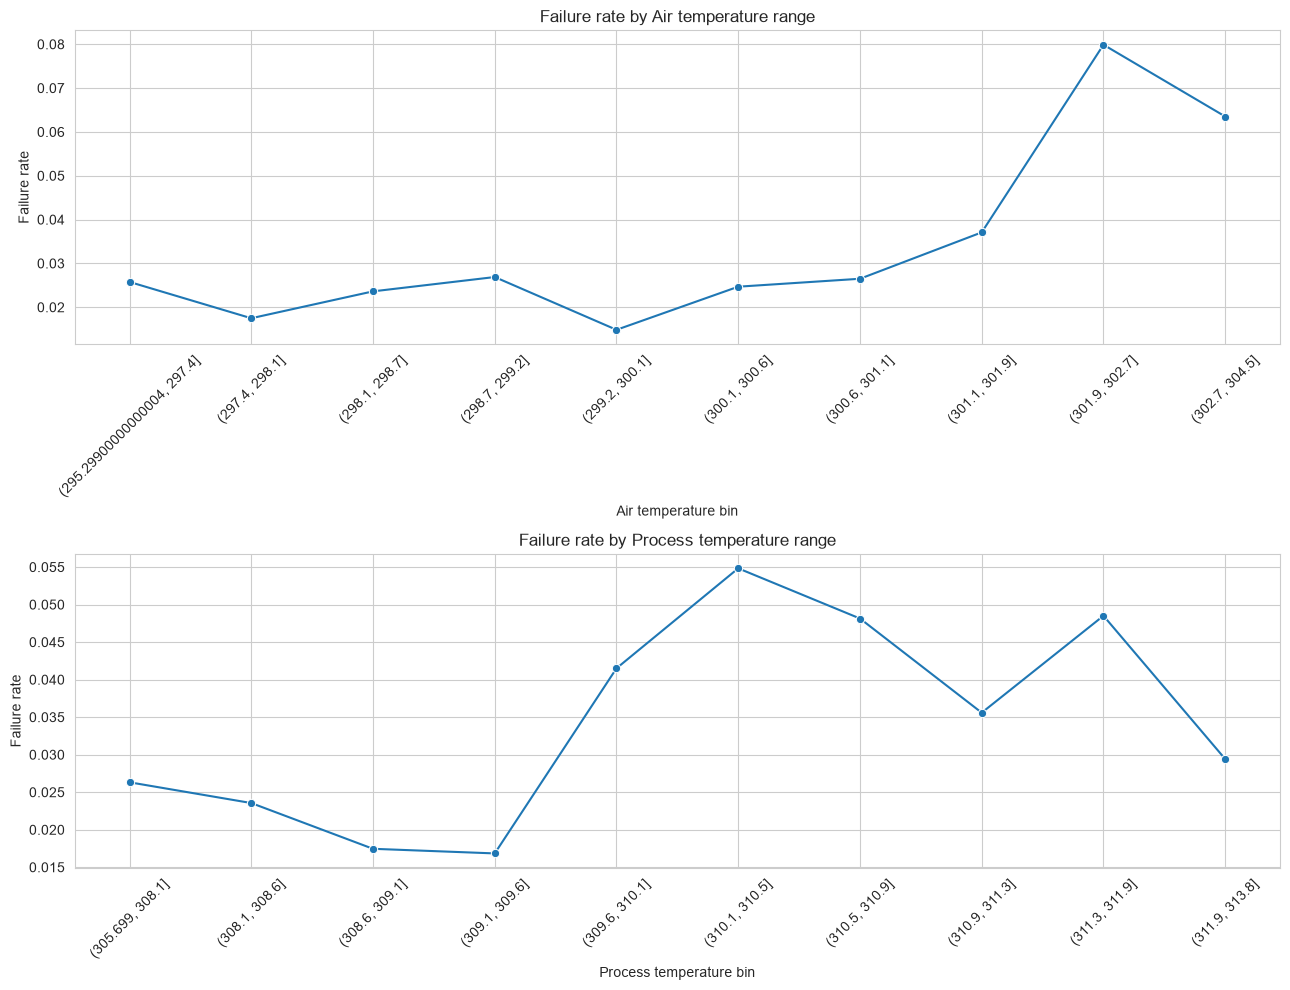

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

sns.lineplot(
    data=air_failure_rate,
    x="Air temperature bin",
    y="Machine failure",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Failure rate by Air temperature range")
axes[0].set_ylabel("Failure rate")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=process_failure_rate,
    x="Process temperature bin",
    y="Machine failure",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Failure rate by Process temperature range")
axes[1].set_ylabel("Failure rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

중복 유형, 유형에는 없는데 오류가 발생한 부분.

UDI - 각 행을 구분하기 위한 순번이므로 기계의 실제 상태나 고장 조건을 나타내지 않는다. 모델이 데이터 순서를 학습할 위험이 있어 제외한다.
Product ID - 제품을 구분하는 식별자이며 대부분 값이 고유하다. 제품 종류 정보는 Type에 이미 포함되어 있으므로 중복 정보가 될 수 있어 제외한다.

In [54]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

target = "Machine failure"

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

eda_df = df[
    numeric_features + ["Type", target]
].copy()

# 그래프에서 0과 1 대신 정상/고장으로 표시
eda_df["Status"] = eda_df[target].map({
    0: "정상",
    1: "고장"
})

# 온도 차이 파생변수
eda_df["Temperature difference [K]"] = (
    eda_df["Process temperature [K]"]
    - eda_df["Air temperature [K]"]
)

eda_df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type,Machine failure,Status,Temperature difference [K]
0,298.1,308.6,1551,42.8,0,M,0,정상,10.5
1,298.2,308.7,1408,46.3,3,L,0,정상,10.5
2,298.1,308.5,1498,49.4,5,L,0,정상,10.4
3,298.2,308.6,1433,39.5,7,L,0,정상,10.4
4,298.2,308.7,1408,40.0,9,L,0,정상,10.5


In [56]:
status_summary = pd.DataFrame({
    "count": eda_df["Status"].value_counts(),
    "ratio(%)": (
        eda_df["Status"].value_counts(normalize=True) * 100
    ).round(2)
})

status_summary

,count,ratio(%)
Status,,
정상,9661,96.61
고장,339,3.39


/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35:

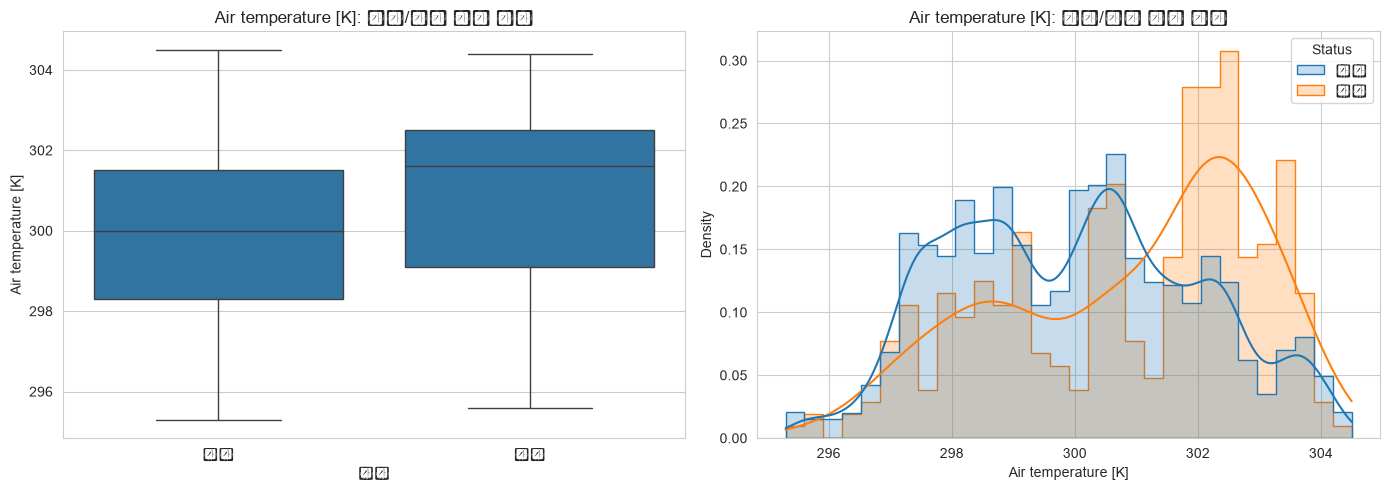

/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35:

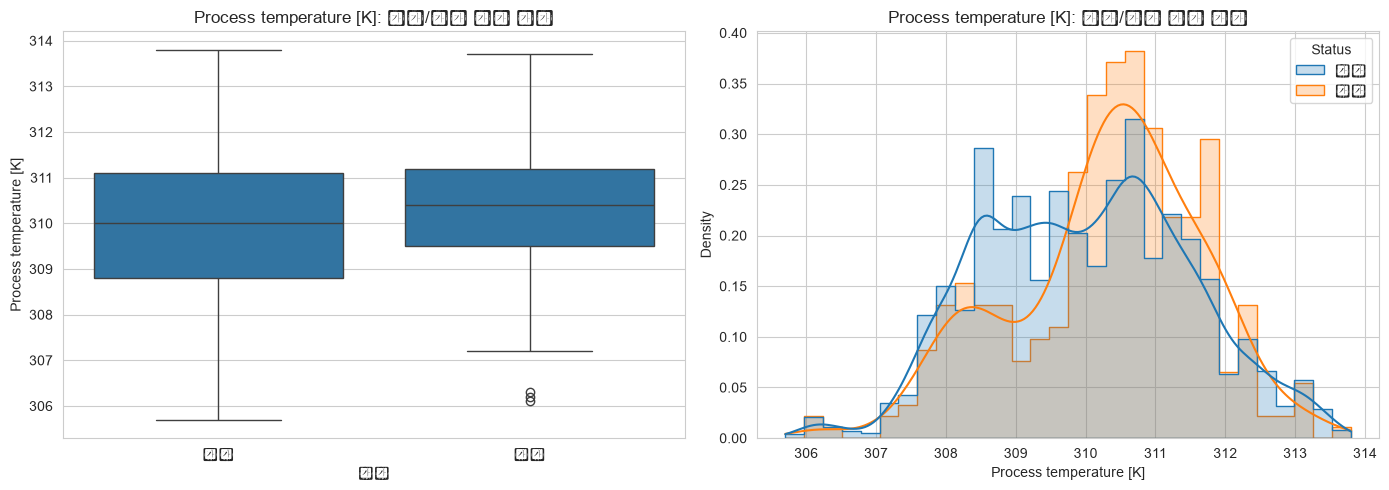

/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35:

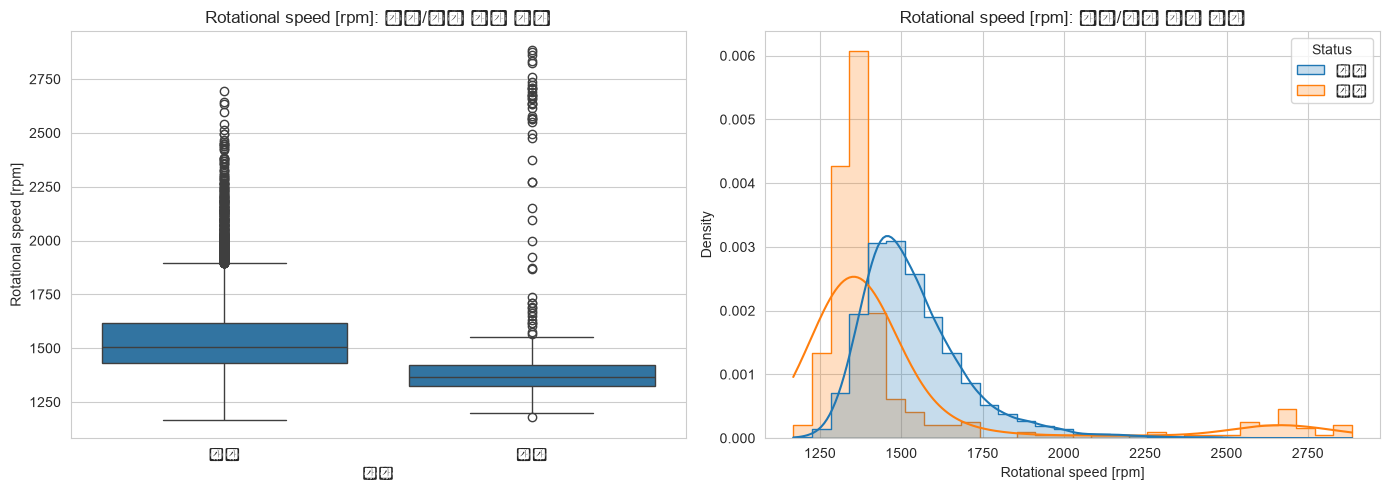

/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35:

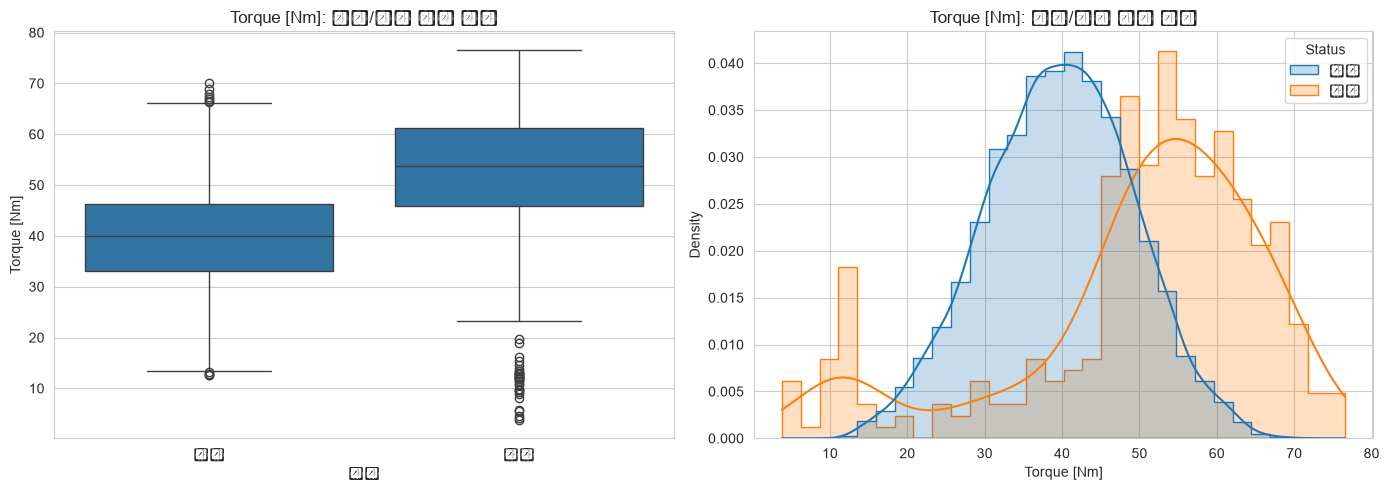

/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/2223364980.py:35:

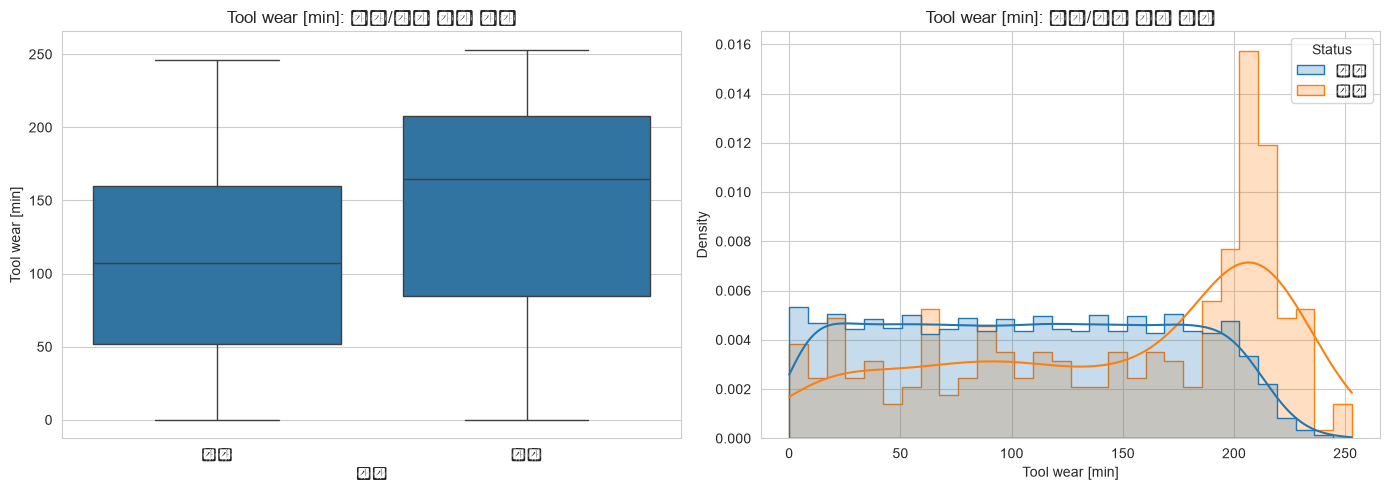

In [57]:
status_order = ["정상", "고장"]

for col in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 박스플롯
    sns.boxplot(
        data=eda_df,
        x="Status",
        y=col,
        order=status_order,
        ax=axes[0]
    )

    axes[0].set_title(f"{col}: 정상/고장 범위 비교")
    axes[0].set_xlabel("상태")

    # 밀도 기준 히스토그램
    sns.histplot(
        data=eda_df,
        x=col,
        hue="Status",
        hue_order=status_order,
        stat="density",
        common_norm=False,
        element="step",
        kde=True,
        bins=30,
        ax=axes[1]
    )

    axes[1].set_title(f"{col}: 정상/고장 분포 비교")
    axes[1].set_ylabel("Density")

    plt.tight_layout()
    plt.show()

In [58]:
single_summary = (
    eda_df.groupby("Status")[numeric_features]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .T
)

single_summary

Status                                   고장           정상
Air temperature [K]     count    339.000000  9661.000000
                        mean     300.886431   299.973999
                        median   301.600000   300.000000
                        std        2.071473     1.990748
                        min      295.600000   295.300000
                        max      304.400000   304.500000
Process temperature [K] count    339.000000  9661.000000
                        mean     310.290265   309.995570
                        median   310.400000   310.000000
                        std        1.363686     1.486846
                        min      306.100000   305.700000
                        max      313.700000   313.800000
Rotational speed [rpm]  count    339.000000  9661.000000
                        mean    1496.486726  1540.260014
                        median  1365.000000  1507.000000
                        std      384.943547   167.394734
                        min     1181.000000  1168.000000
                        max     2886.000000  2695.000000
Torque [Nm]             count    339.000000  9661.000000
                        mean      50.168142    39.629655
                        median    53.700000    39.900000
                        std       16.374498     9.472080
                        min        3.800000    12.600000
                        max       76.600000    70.000000
Tool wear [min]         count    339.000000  9661.000000
                        mean     143.781711   106.693717
                        median   165.000000   107.000000
                        std       72.759876    62.945790
                        min        0.000000     0.000000
                        max      253.000000   246.000000

/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fi

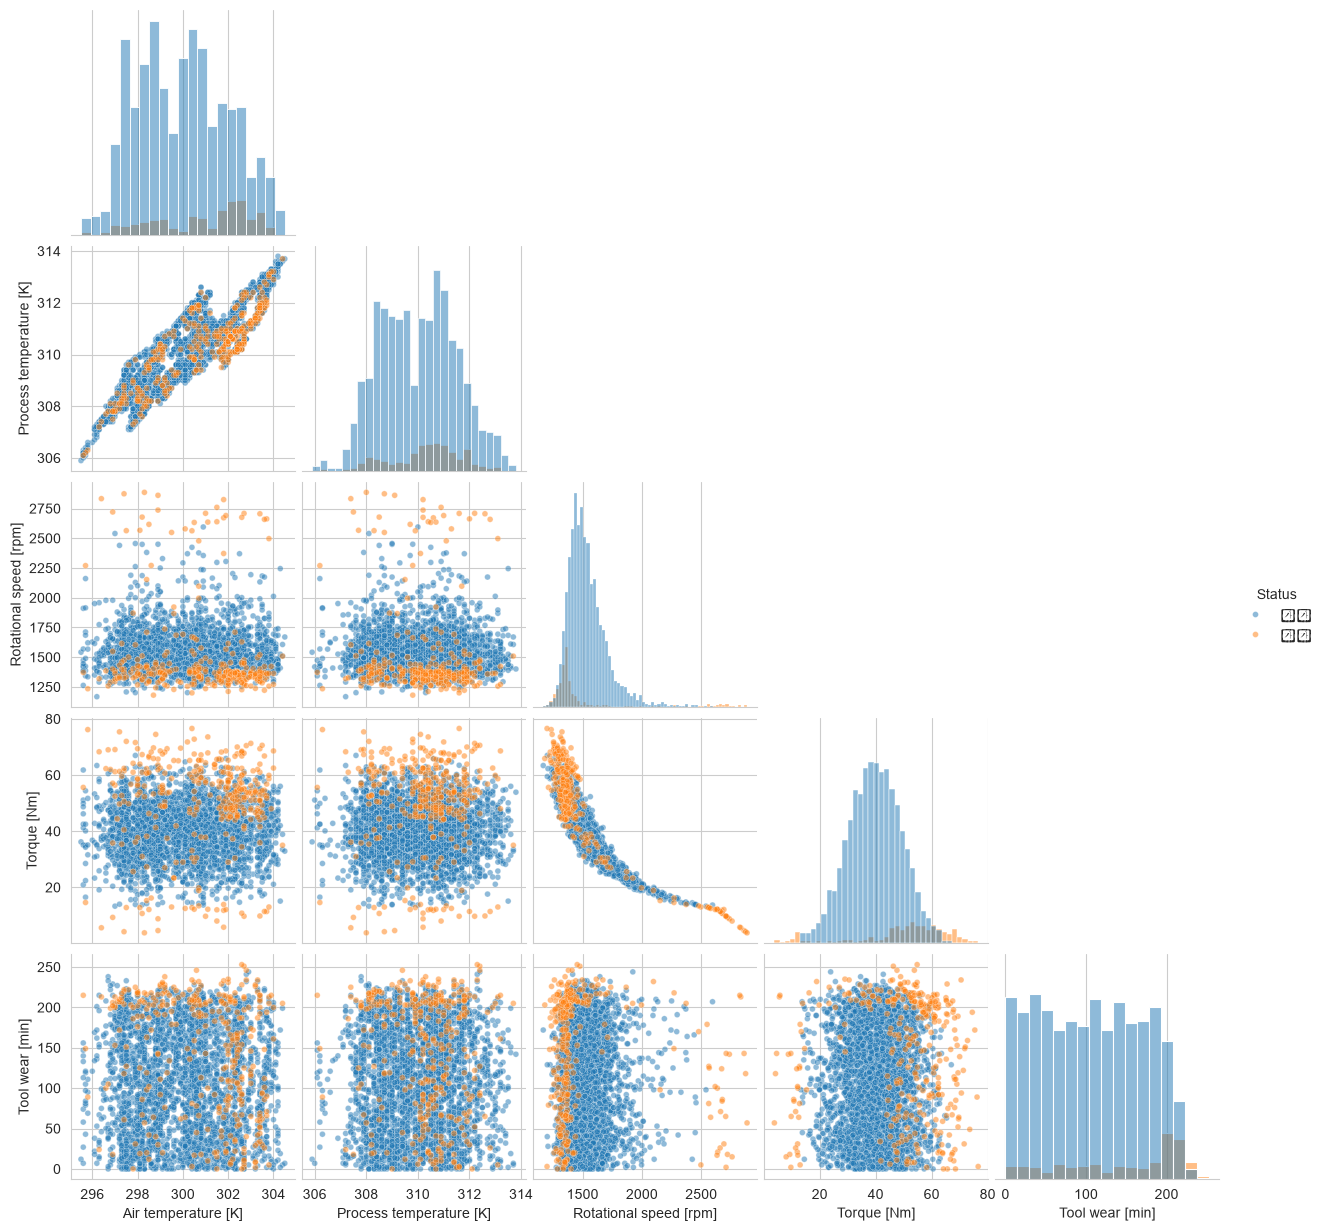

In [59]:
normal_df = eda_df[eda_df["Status"] == "정상"]
failure_df = eda_df[eda_df["Status"] == "고장"]

normal_sample = normal_df.sample(
    n=min(3000, len(normal_df)),
    random_state=42
)

pair_df = pd.concat(
    [normal_sample, failure_df],
    ignore_index=True
)

sns.pairplot(
    pair_df,
    vars=numeric_features,
    hue="Status",
    hue_order=["정상", "고장"],
    corner=True,
    diag_kind="hist",
    plot_kws={
        "alpha": 0.5,
        "s": 18
    }
)

plt.show()

In [60]:
def plot_failure_pair(x_col, y_col):
    normal = eda_df[eda_df["Status"] == "정상"]
    failure = eda_df[eda_df["Status"] == "고장"]

    plt.figure(figsize=(9, 7))

    # 정상 데이터를 먼저 그림
    plt.scatter(
        normal[x_col],
        normal[y_col],
        s=12,
        alpha=0.08,
        label="정상"
    )

    # 고장 데이터를 나중에 그려 위에 표시
    plt.scatter(
        failure[x_col],
        failure[y_col],
        s=28,
        alpha=0.8,
        label="고장"
    )

    plt.title(f"{x_col} + {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


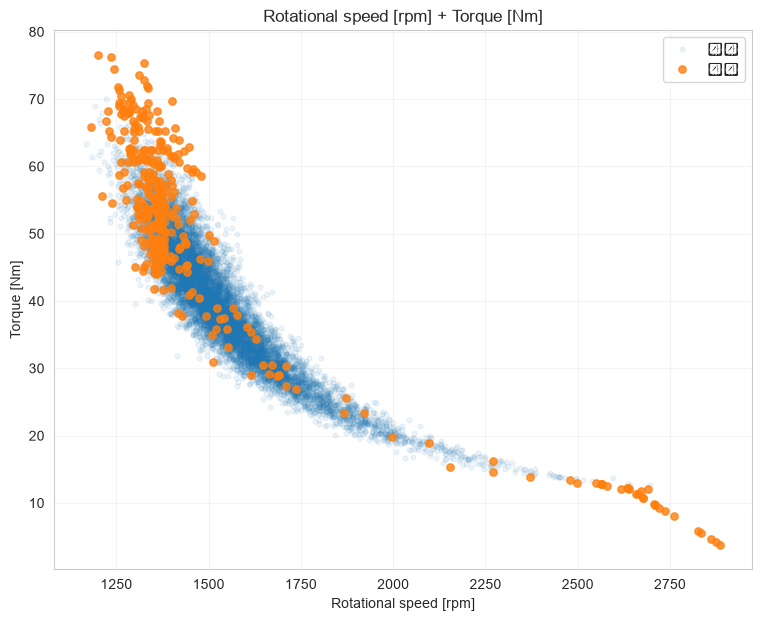

In [61]:
plot_failure_pair(
    "Rotational speed [rpm]",
    "Torque [Nm]"
)

/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


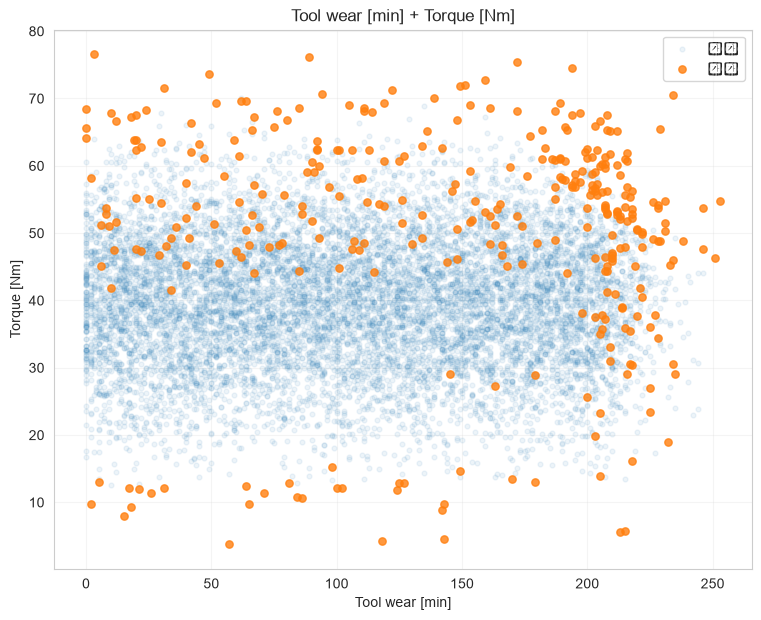

In [62]:
plot_failure_pair(
    "Tool wear [min]",
    "Torque [Nm]"
)

/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


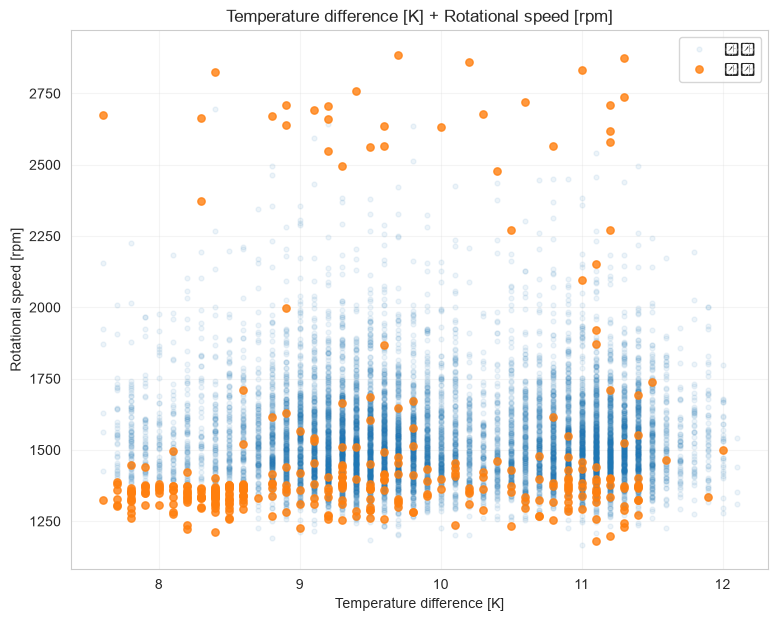

In [63]:
plot_failure_pair(
    "Temperature difference [K]",
    "Rotational speed [rpm]"
)

/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


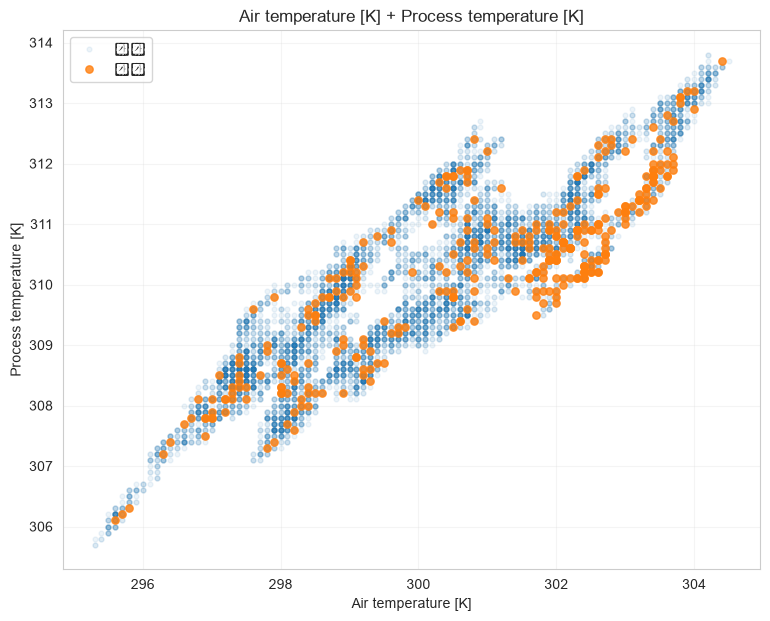

In [64]:
plot_failure_pair(
    "Air temperature [K]",
    "Process temperature [K]"
)

In [65]:
type_summary = (
    eda_df.groupby("Type")[target]
    .agg(
        total_count="count",
        failure_count="sum",
        failure_rate="mean"
    )
    .reset_index()
)

type_summary["failure_rate(%)"] = (
    type_summary["failure_rate"] * 100
).round(2)

type_summary

,Type,total_count,failure_count,failure_rate,failure_rate(%)
0,H,1003,21,0.020937,2.09
1,L,6000,235,0.039167,3.92
2,M,2997,83,0.027694,2.77


/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/

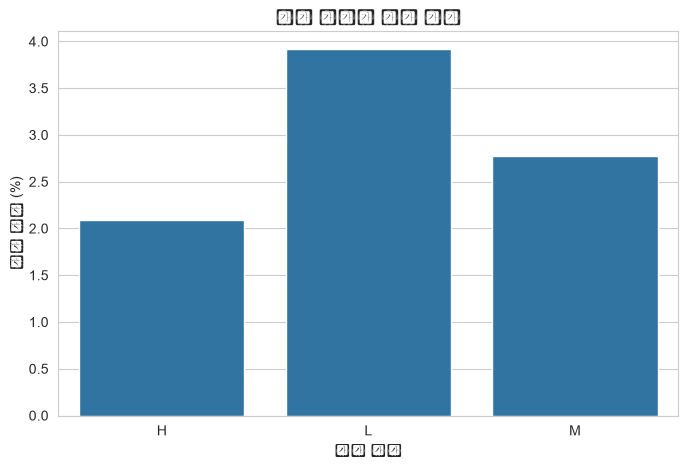

In [66]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=type_summary,
    x="Type",
    y="failure_rate(%)"
)

plt.title("제품 등급별 고장 비율")
plt.xlabel("제품 등급")
plt.ylabel("고장 비율 (%)")
plt.show()

/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  fig.c

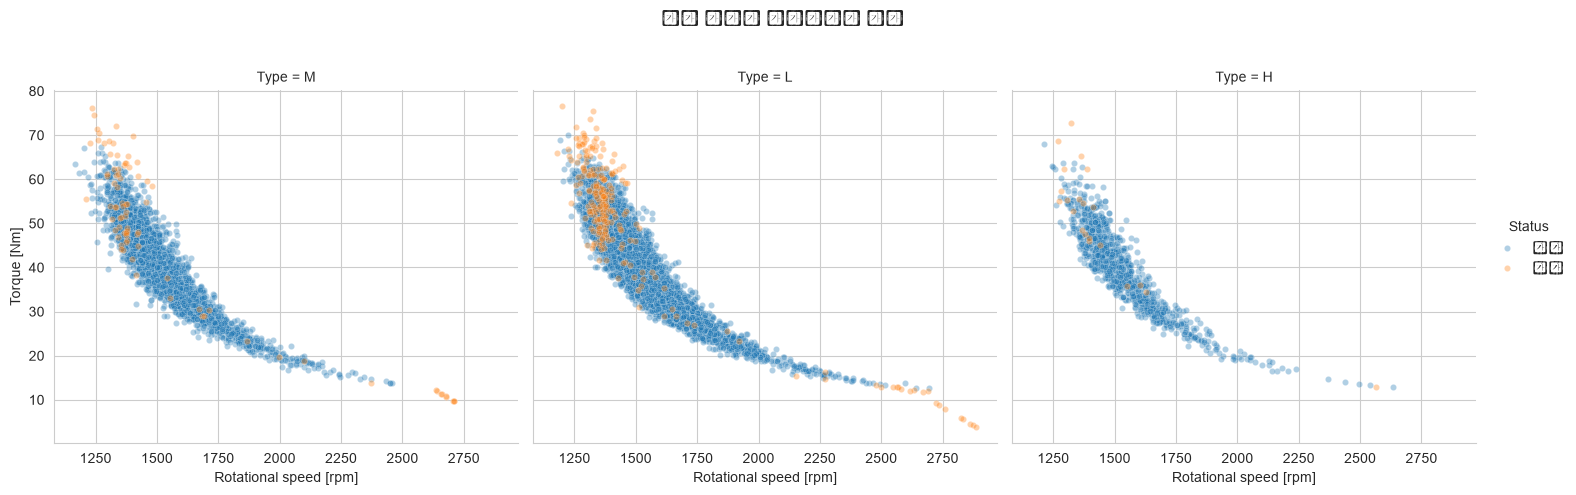

In [67]:
g = sns.FacetGrid(
    eda_df,
    col="Type",
    hue="Status",
    hue_order=["정상", "고장"],
    height=5,
    aspect=1
)

g.map_dataframe(
    sns.scatterplot,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    alpha=0.35,
    s=20
)

g.add_legend()
g.set_axis_labels(
    "Rotational speed [rpm]",
    "Torque [Nm]"
)

g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("제품 등급별 회전속도와 토크")

plt.show()

/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  fig.c

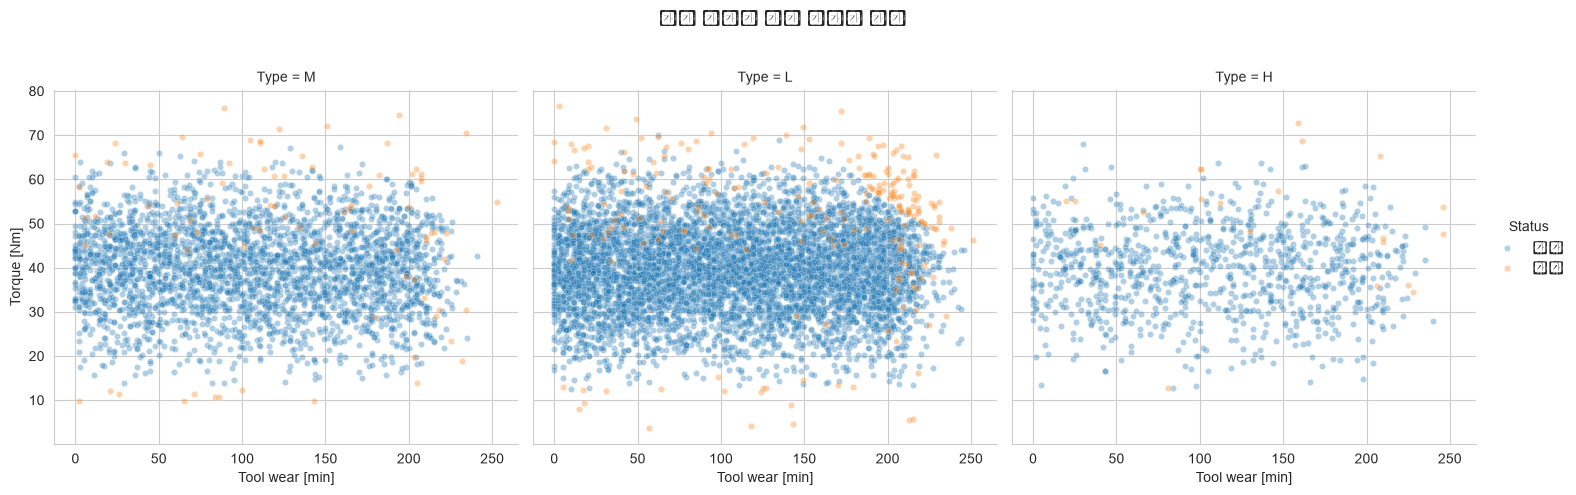

In [68]:
g = sns.FacetGrid(
    eda_df,
    col="Type",
    hue="Status",
    hue_order=["정상", "고장"],
    height=5,
    aspect=1
)

g.map_dataframe(
    sns.scatterplot,
    x="Tool wear [min]",
    y="Torque [Nm]",
    alpha=0.35,
    s=20
)

g.add_legend()
g.set_axis_labels(
    "Tool wear [min]",
    "Torque [Nm]"
)

g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("제품 등급별 공구 마모와 토크")

plt.show()

/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fi

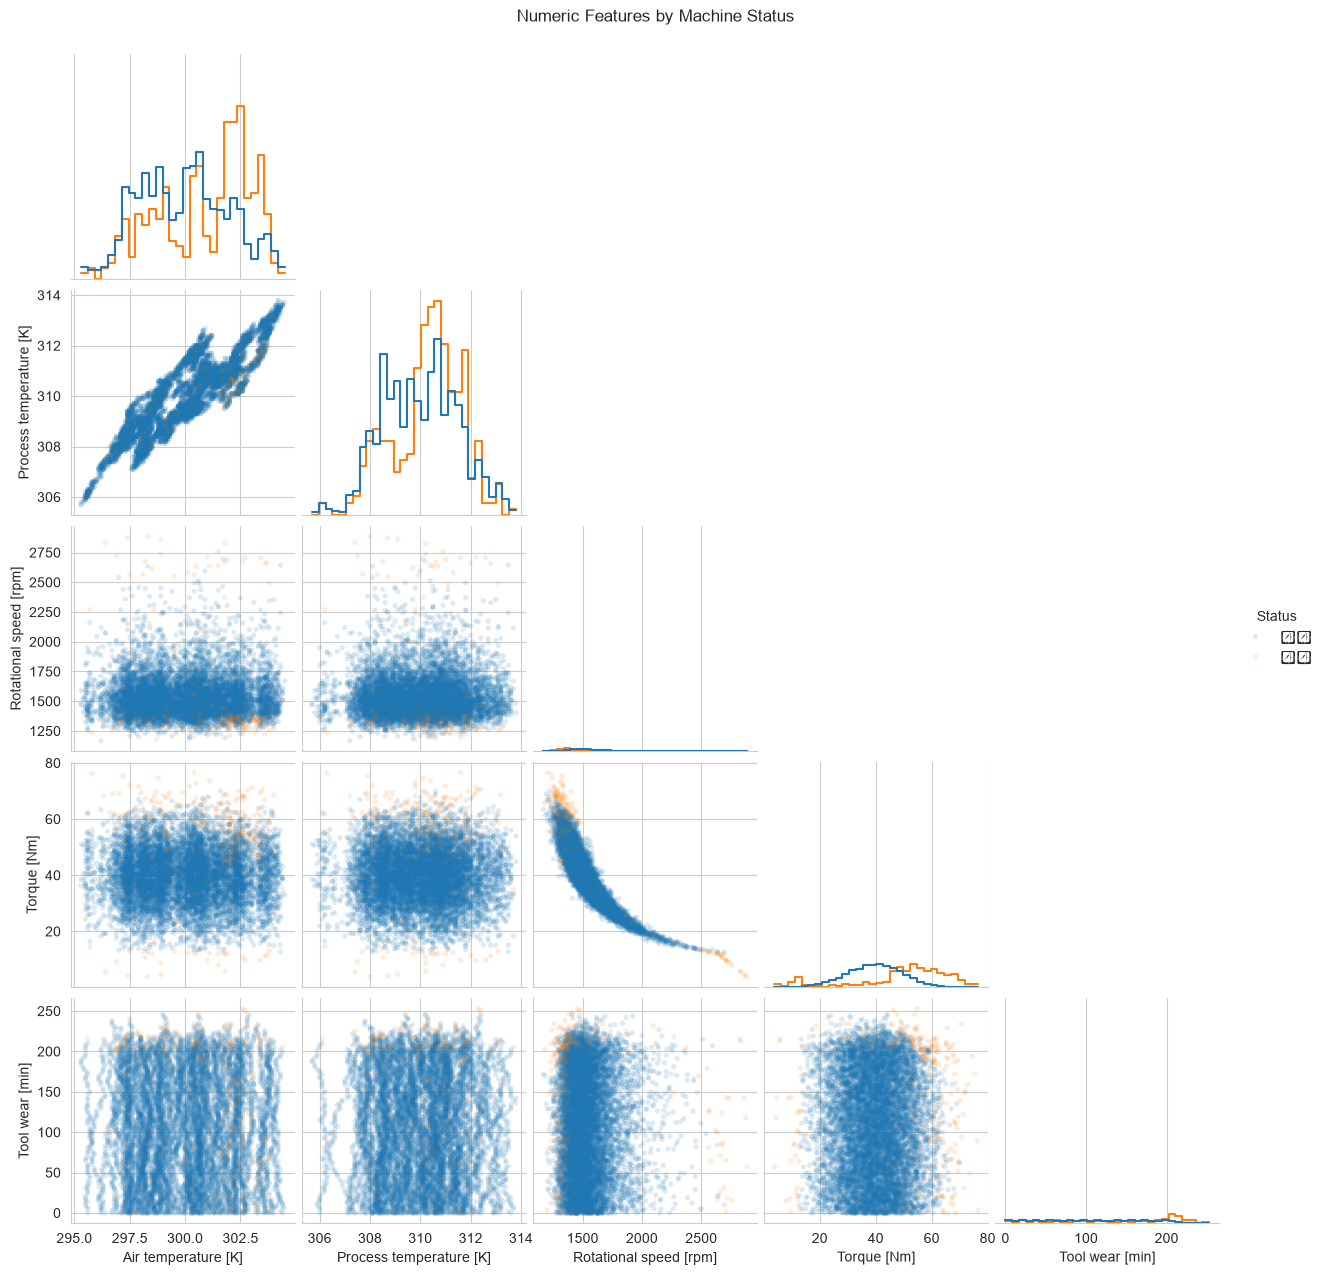

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

pair_df = eda_df[numeric_features + ["Status"]].copy()

g = sns.pairplot(
    pair_df,
    vars=numeric_features,
    hue="Status",
    hue_order=["정상", "고장"],   # 정상을 먼저, 고장을 나중에 그림
    corner=True,
    diag_kind="hist",

    # 산점도 설정
    plot_kws={
        "alpha": 0.15,
        "s": 14,
        "linewidth": 0
    },

    # 대각선 히스토그램 설정
    diag_kws={
        "stat": "density",       # 개수가 아니라 분포 비율 비교
        "common_norm": False,    # 정상/고장을 각각 독립적으로 정규화
        "element": "step",
        "fill": False,
        "bins": 30
    }
)

g.fig.suptitle(
    "Numeric Features by Machine Status",
    y=1.02
)

plt.show()

In [71]:
def plot_failure_pair_all(x_col, y_col):
    normal = eda_df[eda_df["Status"] == "정상"]
    failure = eda_df[eda_df["Status"] == "고장"]

    plt.figure(figsize=(9, 7))

    # 정상 데이터를 먼저, 작고 투명하게 표시
    plt.scatter(
        normal[x_col],
        normal[y_col],
        s=12,
        alpha=0.08,
        label=f"정상 (n={len(normal):,})"
    )

    # 고장 데이터를 나중에, 크고 진하게 표시
    plt.scatter(
        failure[x_col],
        failure[y_col],
        s=35,
        alpha=0.8,
        label=f"고장 (n={len(failure):,})",
        edgecolors="black",
        linewidths=0.3
    )

    plt.title(f"{x_col} + {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/inwoopark/workspace/window_home/7월15일/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


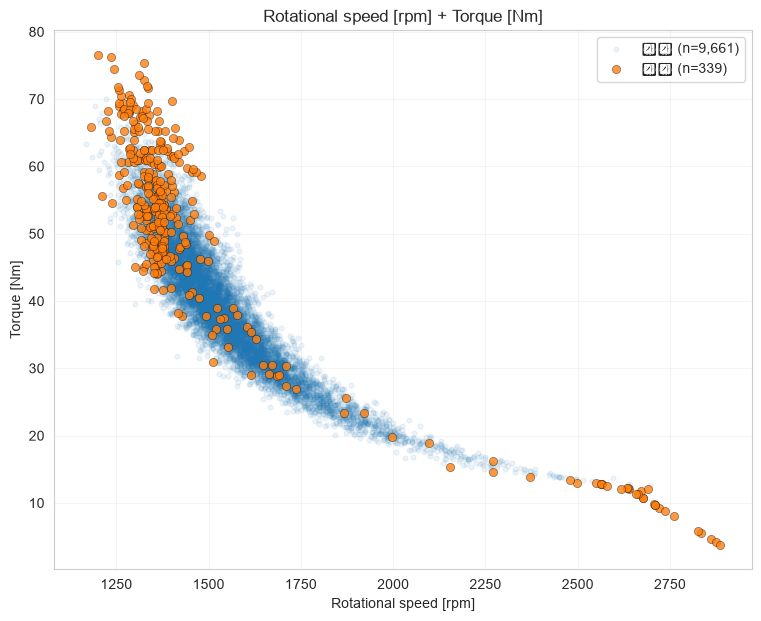

In [72]:
plot_failure_pair_all(
    "Rotational speed [rpm]",
    "Torque [Nm]"
)

In [73]:
import numpy as np

df_fe = df.copy()

# 고속·저토크: 헛돎 후보
df_fe["Free spin index"] = (
    df_fe["Rotational speed [rpm]"]
    / df_fe["Torque [Nm]"]
)

# 기계의 작업 출력
df_fe["Mechanical power [W]"] = (
    df_fe["Torque [Nm]"]
    * 2 * np.pi
    * df_fe["Rotational speed [rpm]"]
    / 60
)

In [74]:
df_fe.groupby("Machine failure")[
    ["Free spin index", "Mechanical power [W]"]
].agg(["count", "mean", "median", "std", "min", "max"])

Free spin index                                              \
                          count       mean     median        std        min   
Machine failure                                                               
0                          9661  42.870074  37.766497  19.142736  17.300435   
1                           339  51.635311  25.243665  89.564043  15.665796   

                            Mechanical power [W]                            \
                        max                count         mean       median   
Machine failure                                                              
0                213.888889                 9661  6244.547534  6243.046225   
1                759.473684                  339  7282.819485  7611.429737   

                                                         
                         std          min           max  
Machine failure                                          
0                1011.394393  3515.033772   8998.024015  
1                1851.137977  1148.440610  10469.923005

/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/792715441.py:26: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/792715441.py:26: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/792715441.py:26: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/792715441.py:26: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/792715441.py:26: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/792715441.py:26: UserW

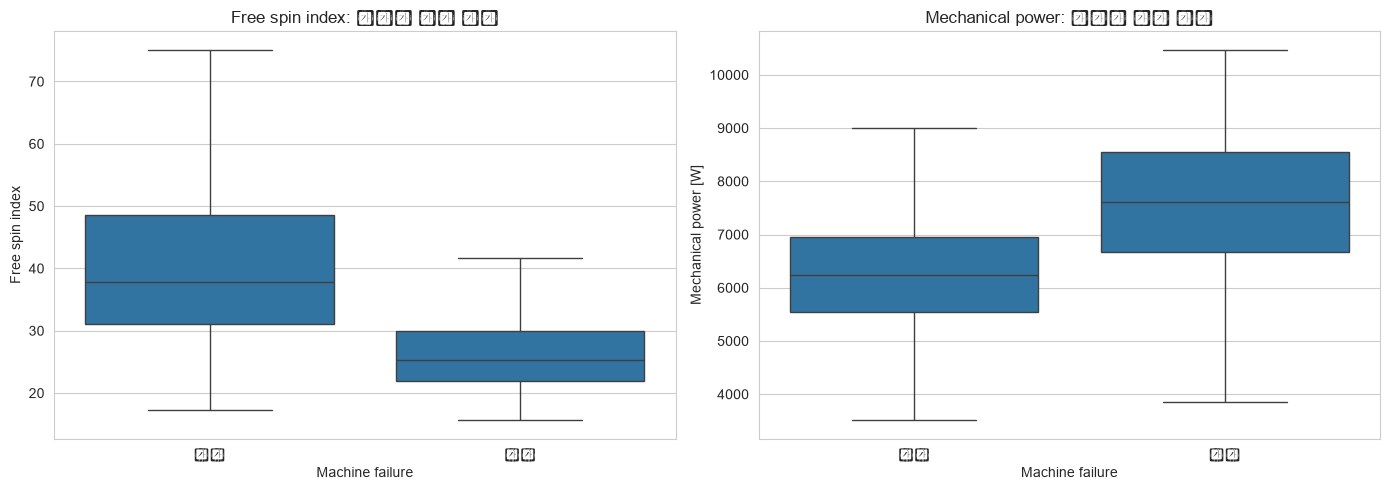

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df_fe,
    x="Machine failure",
    y="Free spin index",
    showfliers=False,
    ax=axes[0]
)
axes[0].set_title("Free spin index: 정상과 고장 비교")
axes[0].set_xticks([0, 1], ["정상", "고장"])

sns.boxplot(
    data=df_fe,
    x="Machine failure",
    y="Mechanical power [W]",
    showfliers=False,
    ax=axes[1]
)
axes[1].set_title("Mechanical power: 정상과 고장 비교")
axes[1].set_xticks([0, 1], ["정상", "고장"])

plt.tight_layout()
plt.show()

회전속도를 토크로 나눈 Free spin index를 생성하여 정상과 고장을 비교한 결과, 예상과 달리 고장 그룹의 지표가 정상 그룹보다 낮게 나타났다. 이는 고속·저토크의 헛돎 상태보다 회전속도에 비해 토크가 큰 저속·고부하 상태가 전체 고장과 더 관련 있을 가능성을 보여준다. 반면 회전속도와 토크를 결합한 기계적 출력은 고장 그룹에서 더 높게 나타나, 높은 작업 출력과 기계 부담이 고장과 관련된 주요 상태일 수 있다고 판단했다. 다만 Machine failure에는 여러 고장 유형이 포함되어 있으므로 헛돎 가설은 전체 고장보다 특정 고장 유형이나 극단 구간을 대상으로 추가 확인할 필요가 있다.


In [77]:
df_fe["Free spin group"] = pd.qcut(
    df_fe["Free spin index"],
    q=10,
    duplicates="drop"
)

free_spin_rate = (
    df_fe.groupby("Free spin group", observed=True)
    .agg(
        data_count=("Machine failure", "size"),
        failure_count=("Machine failure", "sum"),
        failure_rate=("Machine failure", "mean")
    )
    .reset_index()
)

free_spin_rate["failure_rate(%)"] = (
    free_spin_rate["failure_rate"] * 100
).round(2)

free_spin_rate

,Free spin group,data_count,failure_count,failure_rate,failure_rate(%)
0,"(15.665000000000001, 26.12]",1000,185,0.185,18.5
1,"(26.12, 29.195]",1000,55,0.055,5.5
2,"(29.195, 31.772]",1000,26,0.026,2.6
3,"(31.772, 34.361]",1000,8,0.008,0.8
4,"(34.361, 37.404]",1000,4,0.004,0.4
5,"(37.404, 40.901]",1000,4,0.004,0.4
6,"(40.901, 45.367]",1000,7,0.007,0.7
7,"(45.367, 51.987]",1000,4,0.004,0.4
8,"(51.987, 63.993]",1000,8,0.008,0.8
9,"(63.993, 759.474]",1000,38,0.038,3.8


In [78]:
df_fe["Power group"] = pd.qcut(
    df_fe["Mechanical power [W]"],
    q=10,
    duplicates="drop"
)

power_rate = (
    df_fe.groupby("Power group", observed=True)
    .agg(
        data_count=("Machine failure", "size"),
        failure_count=("Machine failure", "sum"),
        failure_rate=("Machine failure", "mean")
    )
    .reset_index()
)

power_rate["failure_rate(%)"] = (
    power_rate["failure_rate"] * 100
).round(2)

power_rate

,Power group,data_count,failure_count,failure_rate,failure_rate(%)
0,"(1148.44, 4914.985]",1000,40,0.040,4.0
1,"(4914.985, 5383.01]",1000,6,0.006,0.6
2,"(5383.01, 5717.834]",1000,5,0.005,0.5
3,"(5717.834, 6007.911]",1000,8,0.008,0.8
4,"(6007.911, 6271.027]",1000,12,0.012,1.2
5,"(6271.027, 6546.606]",1000,9,0.009,0.9
6,"(6546.606, 6833.233]",1000,24,0.024,2.4
7,"(6833.233, 7176.204]",1000,26,0.026,2.6
8,"(7176.204, 7640.576]",1000,40,0.040,4.0
9,"(7640.576, 10469.923]",1000,169,0.169,16.9


회전속도와 토크의 비율을 구간별로 비교한 결과, 비율이 지나치게 낮은 저속·고부하 상태에서 고장률이 18.5%로 가장 높게 나타났다. 반대로 고속·저토크 상태를 나타내는 높은 비율 구간에서도 고장률이 중간 구간보다 증가했지만 그 영향은 상대적으로 작았다. 또한 회전속도와 토크를 결합한 기계적 출력은 최고 출력 구간에서 고장률이 16.9%까지 증가했다. 따라서 기계의 고장은 단순한 헛돎보다는 저속·고부하 및 지나치게 높은 출력과 더 강하게 관련된 것으로 판단했다.

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [80]:
# 그래프에서 사용할 구간 번호 생성
free_spin_plot = free_spin_rate.copy()
power_plot = power_rate.copy()

free_spin_plot["구간"] = range(1, len(free_spin_plot) + 1)
power_plot["구간"] = range(1, len(power_plot) + 1)

# 전체 평균 고장률
overall_failure_rate = df_fe["Machine failure"].mean() * 100

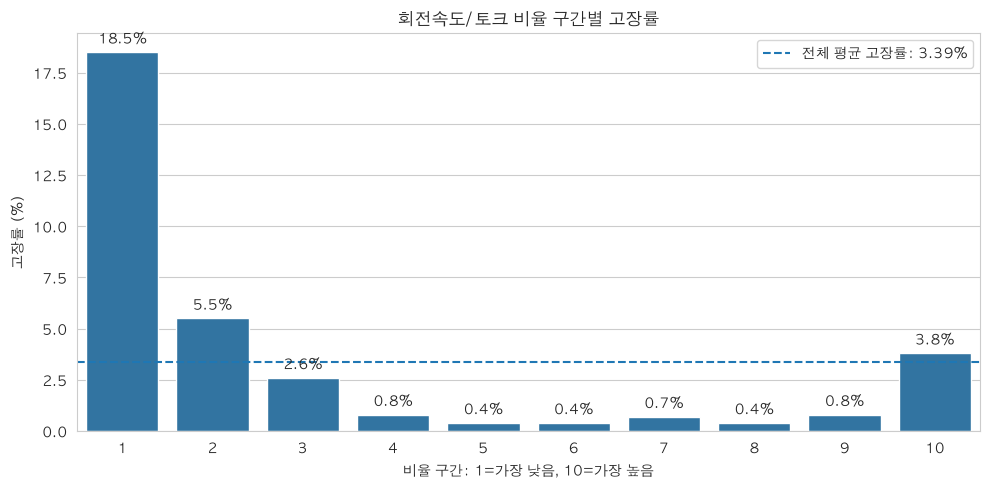

In [81]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=free_spin_plot,
    x="구간",
    y="failure_rate(%)"
)

# 전체 평균 고장률 표시
plt.axhline(
    overall_failure_rate,
    linestyle="--",
    label=f"전체 평균 고장률: {overall_failure_rate:.2f}%"
)

# 각 막대 위에 고장률 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title("회전속도/토크 비율 구간별 고장률")
plt.xlabel("비율 구간: 1=가장 낮음, 10=가장 높음")
plt.ylabel("고장률 (%)")
plt.legend()
plt.tight_layout()
plt.show()

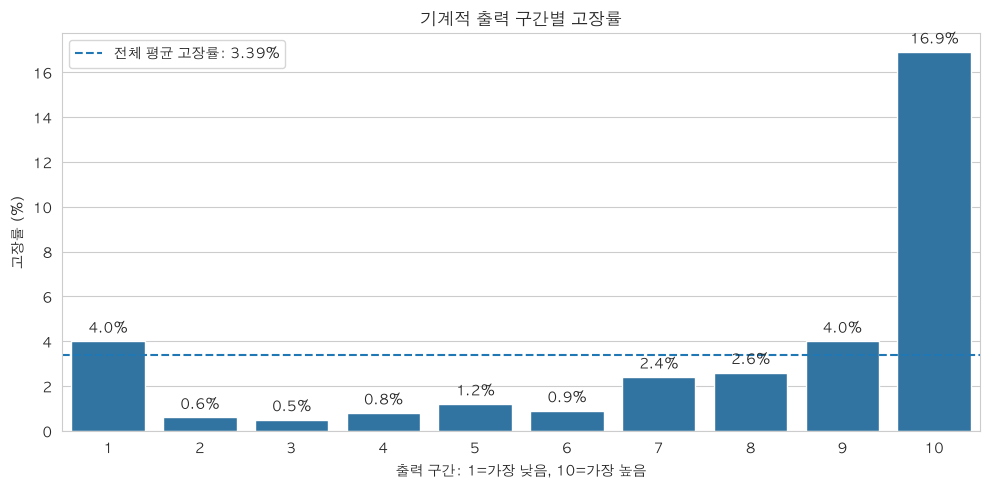

In [82]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=power_plot,
    x="구간",
    y="failure_rate(%)"
)

plt.axhline(
    overall_failure_rate,
    linestyle="--",
    label=f"전체 평균 고장률: {overall_failure_rate:.2f}%"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title("기계적 출력 구간별 고장률")
plt.xlabel("출력 구간: 1=가장 낮음, 10=가장 높음")
plt.ylabel("고장률 (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
def plot_failure_composition(
    result_df,
    title,
    xlabel
):
    plot_df = result_df.copy()
    plot_df["구간"] = range(1, len(plot_df) + 1)

    # 고장률과 정상률
    plot_df["고장"] = plot_df["failure_rate(%)"]
    plot_df["정상"] = 100 - plot_df["고장"]

    plt.figure(figsize=(10, 5))

    # 고장을 아래쪽에 표시
    plt.bar(
        plot_df["구간"],
        plot_df["고장"],
        label="고장"
    )

    # 정상은 고장 막대 위에 누적
    plt.bar(
        plot_df["구간"],
        plot_df["정상"],
        bottom=plot_df["고장"],
        label="정상",
        alpha=0.45
    )

    # 고장률 숫자 표시
    for x, rate in zip(plot_df["구간"], plot_df["고장"]):
        plt.text(
            x,
            rate + 1,
            f"{rate:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("구간 내 데이터 비율 (%)")
    plt.ylim(0, 108)
    plt.xticks(plot_df["구간"])
    plt.legend()
    plt.tight_layout()
    plt.show()

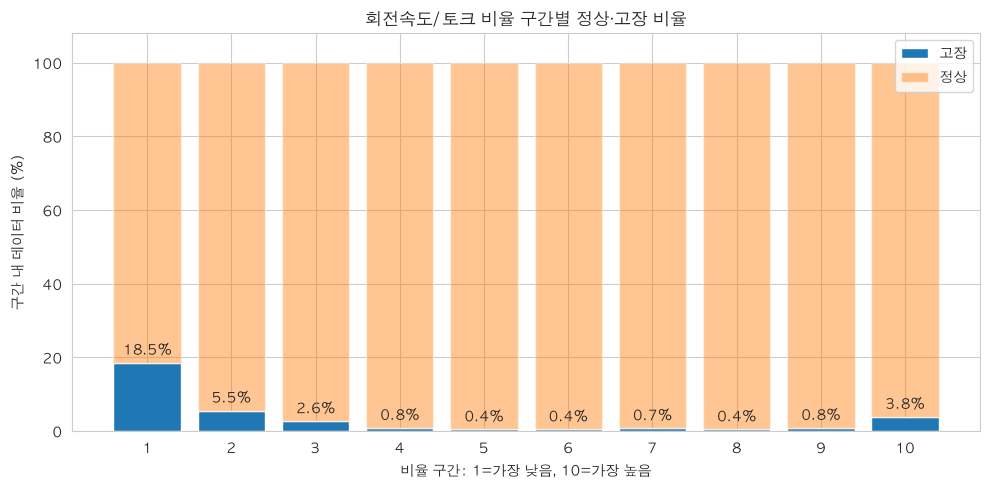

In [89]:
plot_failure_composition(
    free_spin_rate,
    "회전속도/토크 비율 구간별 정상·고장 비율",
    "비율 구간: 1=가장 낮음, 10=가장 높음"
)

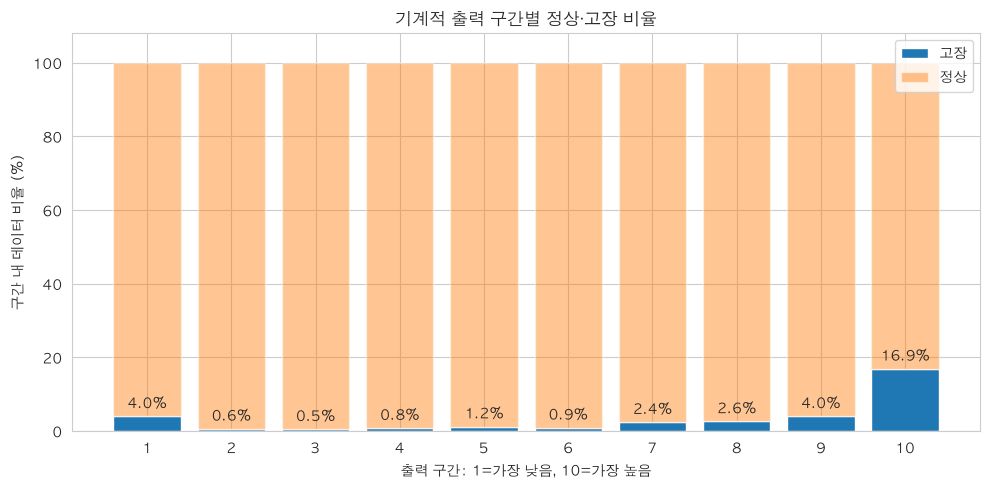

In [85]:
plot_failure_composition(
    power_rate,
    "기계적 출력 구간별 정상·고장 비율",
    "출력 구간: 1=가장 낮음, 10=가장 높음"
)

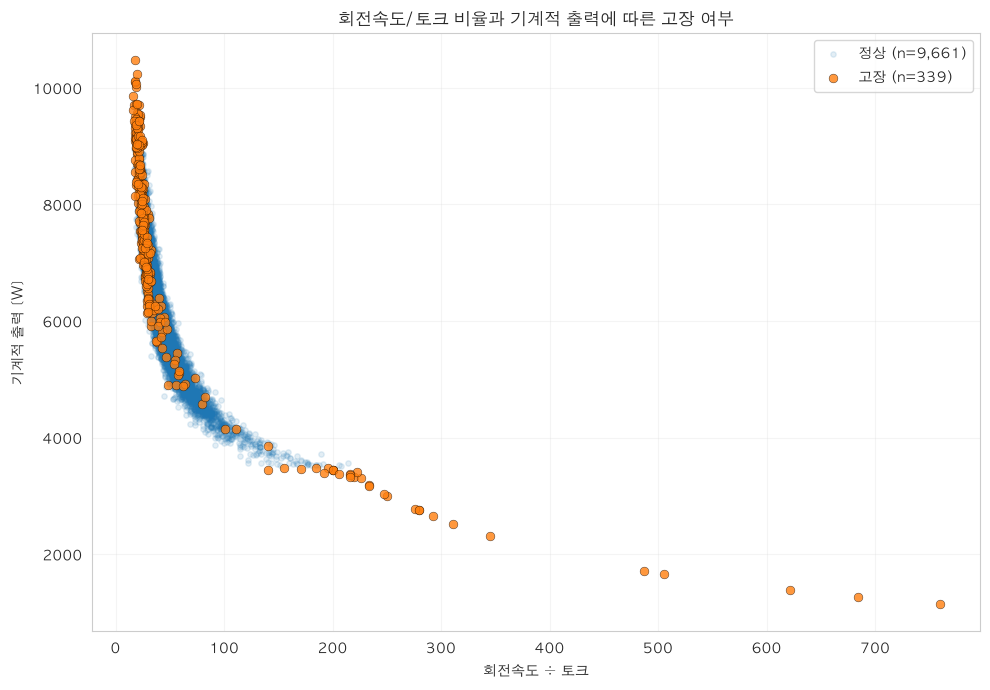

In [86]:
df_fe["상태"] = df_fe["Machine failure"].map({
    0: "정상",
    1: "고장"
})

normal_df = df_fe[df_fe["Machine failure"] == 0]
failure_df = df_fe[df_fe["Machine failure"] == 1]

plt.figure(figsize=(10, 7))

# 정상 데이터를 먼저 작고 투명하게 표시
plt.scatter(
    normal_df["Free spin index"],
    normal_df["Mechanical power [W]"],
    s=15,
    alpha=0.12,
    label=f"정상 (n={len(normal_df):,})"
)

# 고장 데이터를 위에 표시
plt.scatter(
    failure_df["Free spin index"],
    failure_df["Mechanical power [W]"],
    s=40,
    alpha=0.8,
    edgecolors="black",
    linewidths=0.3,
    label=f"고장 (n={len(failure_df):,})"
)

plt.title("회전속도/토크 비율과 기계적 출력에 따른 고장 여부")
plt.xlabel("회전속도 ÷ 토크")
plt.ylabel("기계적 출력 [W]")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

df_fe["상태"] = df_fe["Machine failure"].map({
    0: "정상",
    1: "고장"
})

In [91]:
def plot_failure_distribution(data, feature, title=None, log_scale=False):
    plt.figure(figsize=(10, 5))

    sns.kdeplot(
        data=data,
        x=feature,
        hue="상태",
        hue_order=["정상", "고장"],
        common_norm=False,   # 정상·고장을 각각 독립적으로 밀도 계산
        fill=True,
        alpha=0.25,
        linewidth=2,
        log_scale=log_scale
    )

    plt.title(title or f"{feature}: 정상·고장 분포 비교")
    plt.xlabel(feature)
    plt.ylabel("밀도")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

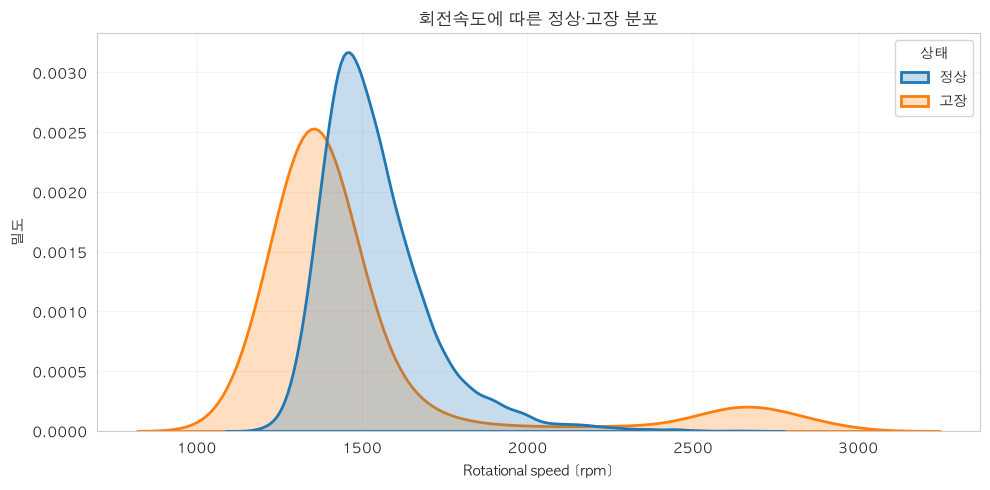

In [92]:
plot_failure_distribution(
    df_fe,
    "Rotational speed [rpm]",
    "회전속도에 따른 정상·고장 분포"
)

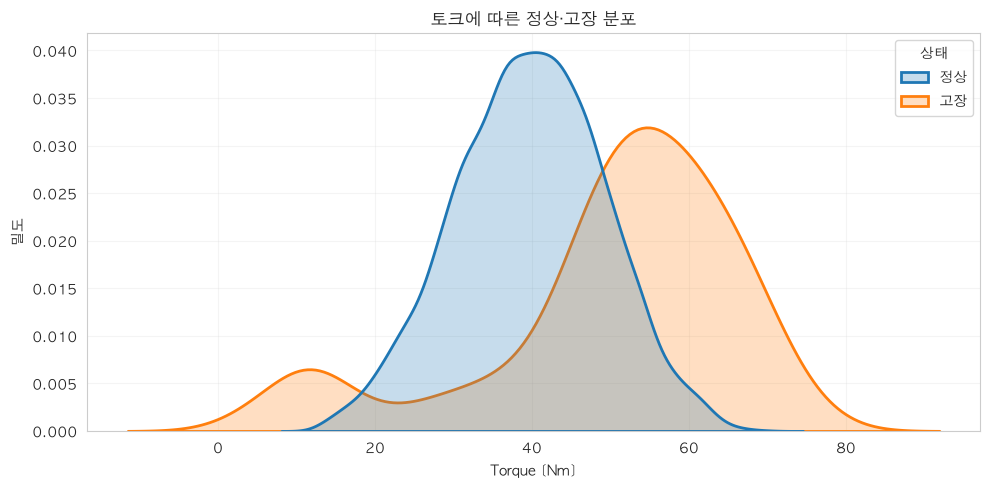

In [93]:
plot_failure_distribution(
    df_fe,
    "Torque [Nm]",
    "토크에 따른 정상·고장 분포"
)

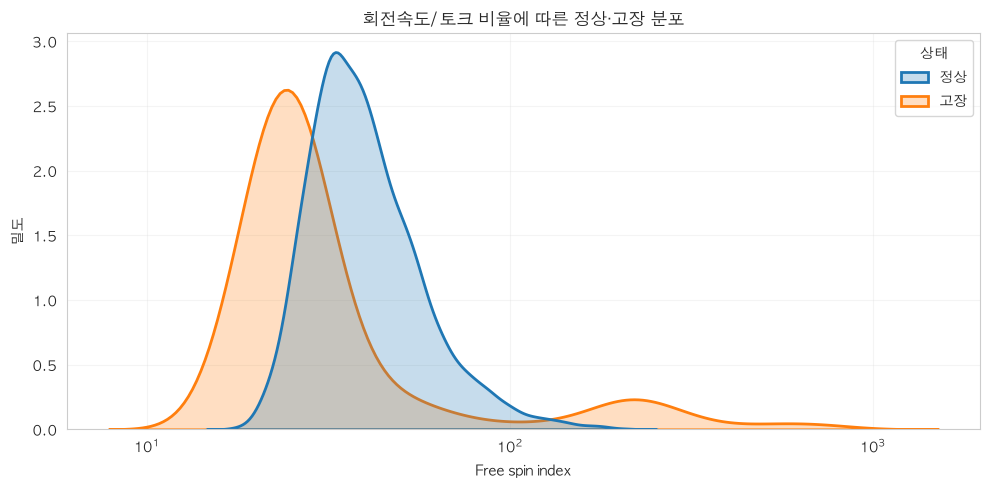

In [94]:
plot_failure_distribution(
    df_fe,
    "Free spin index",
    "회전속도/토크 비율에 따른 정상·고장 분포",
    log_scale=True
)

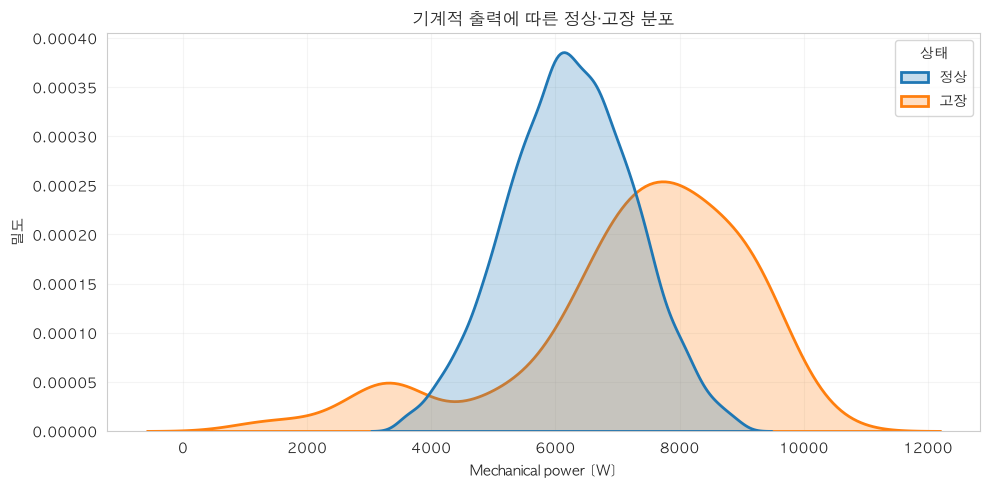

In [95]:
plot_failure_distribution(
    df_fe,
    "Mechanical power [W]",
    "기계적 출력에 따른 정상·고장 분포"
)

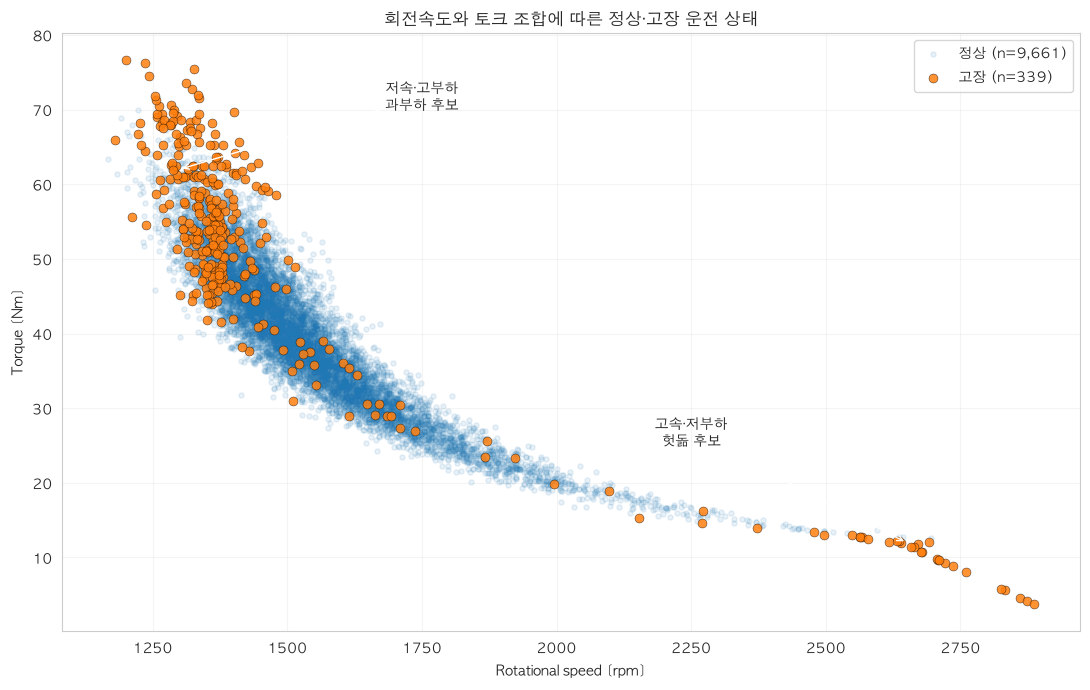

In [96]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

normal_df = df_fe[df_fe["Machine failure"] == 0]
failure_df = df_fe[df_fe["Machine failure"] == 1]

plt.figure(figsize=(11, 7))

# 정상 데이터
plt.scatter(
    normal_df["Rotational speed [rpm]"],
    normal_df["Torque [Nm]"],
    s=14,
    alpha=0.10,
    label=f"정상 (n={len(normal_df):,})"
)

# 고장 데이터
plt.scatter(
    failure_df["Rotational speed [rpm]"],
    failure_df["Torque [Nm]"],
    s=42,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.3,
    label=f"고장 (n={len(failure_df):,})"
)

# 주요 영역 설명
plt.annotate(
    "저속·고부하\n과부하 후보",
    xy=(1300, 62),
    xytext=(1750, 70),
    arrowprops={"arrowstyle": "->"},
    ha="center"
)

plt.annotate(
    "고속·저부하\n헛돎 후보",
    xy=(2650, 12),
    xytext=(2250, 25),
    arrowprops={"arrowstyle": "->"},
    ha="center"
)

plt.title("회전속도와 토크 조합에 따른 정상·고장 운전 상태")
plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

/var/folders/kp/12vvzgyj3g35ck4177l3n6yr0000gn/T/ipykernel_31122/1238380917.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="상태")


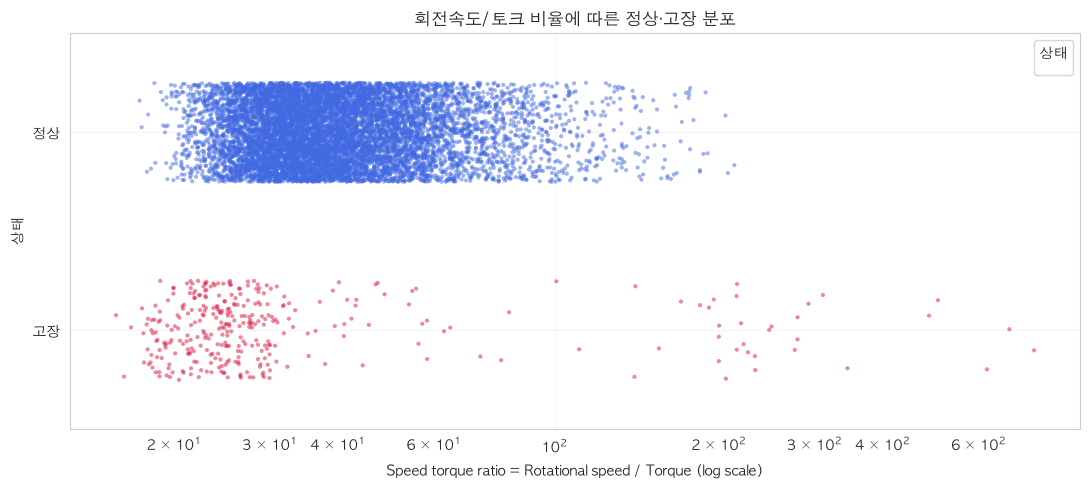

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# 비율 변수 생성
df_plot = df.copy()

df_plot["Speed torque ratio"] = (
    df_plot["Rotational speed [rpm]"] / df_plot["Torque [Nm]"]
)

# 상태 라벨
df_plot["Status"] = df_plot["Machine failure"].map({
    0: "정상",
    1: "고장"
})

plt.figure(figsize=(11, 5))

sns.stripplot(
    data=df_plot,
    x="Speed torque ratio",
    y="Status",
    hue="Status",
    order=["정상", "고장"],
    hue_order=["정상", "고장"],
    palette={"정상": "royalblue", "고장": "crimson"},
    jitter=0.25,
    alpha=0.5,
    size=3
)

plt.xscale("log")
plt.title("회전속도/토크 비율에 따른 정상·고장 분포")
plt.xlabel("Speed torque ratio = Rotational speed / Torque (log scale)")
plt.ylabel("상태")
plt.grid(alpha=0.2)
plt.legend(title="상태")
plt.tight_layout()
plt.show()

In [99]:
import pandas as pd

df = pd.read_csv("ai4i2020.csv")

# Part A에서 만든 파생변수
df["Torque_Speed"] = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
)

feature_cols = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Torque_Speed",
]

target_cols = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
]

X = df[feature_cols].copy()
y = df[target_cols].copy()

print("입력 데이터:", X.shape)
print("Target 데이터:", y.shape)

print("\n입력 변수")
print(X.columns.tolist())

print("\n고장 유형별 발생 건수")
print(y.sum())

입력 데이터: (10000, 7)
Target 데이터: (10000, 5)

입력 변수
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Torque_Speed']

고장 유형별 발생 건수
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


In [100]:
failure_check = (df[target_cols].sum(axis=1) > 0).astype(int)

print(
    "Machine failure 일치 여부:",
    (failure_check == df["Machine failure"]).all()
)

Machine failure 일치 여부: False


In [101]:
target_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# 각 행에서 발생한 고장 유형 개수
df["failure_type_count"] = df[target_cols].sum(axis=1)

# 0개, 1개, 2개 이상 발생한 행 수 확인
print(df["failure_type_count"].value_counts().sort_index())

failure_type_count
0    9652
1     324
2      23
3       1
Name: count, dtype: int64


In [102]:
multi_failure_df = df[df["failure_type_count"] >= 2]

print("다중 고장 발생 행 수:", len(multi_failure_df))

display(
    multi_failure_df[
        [
            "UDI",
            "Product ID",
            "Machine failure",
            "TWF",
            "HDF",
            "PWF",
            "OSF",
            "RNF",
            "failure_type_count",
        ]
    ].head(20)
)

다중 고장 발생 행 수: 24


,UDI,Product ID,Machine failure,TWF,HDF,PWF,OSF,RNF,failure_type_count
69,70,L47249,1,0,0,1,1,0,2
1324,1325,M16184,1,0,0,1,1,0,2
1496,1497,L48676,1,0,0,1,1,0,2
3611,3612,L50791,1,1,0,0,0,1,2
3854,3855,L51034,1,0,0,1,1,0,2
3943,3944,L51123,1,0,0,1,1,0,2
4254,4255,L51434,1,0,1,1,0,0,2
4342,4343,M19202,1,0,1,1,0,0,2
4370,4371,L51550,1,0,1,0,1,0,2
4383,4384,L51563,1,0,1,0,1,0,2


In [103]:
def get_failure_types(row):
    return ", ".join(
        failure
        for failure in target_cols
        if row[failure] == 1
    )

multi_failure_df = multi_failure_df.copy()

multi_failure_df["failure_combination"] = multi_failure_df.apply(
    get_failure_types,
    axis=1,
)

print(
    multi_failure_df["failure_combination"]
    .value_counts()
)

failure_combination
PWF, OSF         11
HDF, OSF          6
HDF, PWF          3
TWF, OSF          2
TWF, RNF          1
TWF, PWF, OSF     1
Name: count, dtype: int64


In [104]:
failure_counts = df[target_cols].sum().sort_values(ascending=False)

failure_distribution = pd.DataFrame({
    "고장 건수": failure_counts,
    "전체 데이터 대비 비율(%)": (
        failure_counts / len(df) * 100
    ).round(2),
})

display(failure_distribution)

,고장 건수,전체 데이터 대비 비율(%)
HDF,115,1.15
OSF,98,0.98
PWF,95,0.95
TWF,46,0.46
RNF,19,0.19


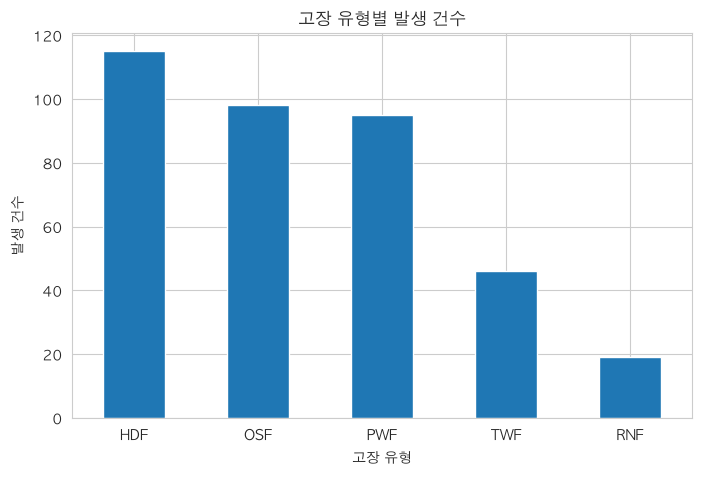

In [105]:
import matplotlib.pyplot as plt

failure_counts.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.title("고장 유형별 발생 건수")
plt.xlabel("고장 유형")
plt.ylabel("발생 건수")
plt.xticks(rotation=0)
plt.show()

In [106]:
failure_label_ratio = (
    failure_counts
    / failure_counts.sum()
    * 100
).round(2)

failure_summary = pd.DataFrame({
    "고장 건수": failure_counts,
    "고장 라벨 중 비율(%)": failure_label_ratio,
})

display(failure_summary)

,고장 건수,고장 라벨 중 비율(%)
HDF,115,30.83
OSF,98,26.27
PWF,95,25.47
TWF,46,12.33
RNF,19,5.09


In [107]:
# 하나 이상의 고장 유형이 표시된 행 수
failure_row_count = (
    df[target_cols].sum(axis=1) >= 1
).sum()

# 다섯 고장 유형의 전체 발생 횟수
failure_label_count = df[target_cols].sum().sum()

print("고장 유형이 하나 이상인 행 수:", failure_row_count)
print("고장 라벨의 총 발생 횟수:", failure_label_count)

고장 유형이 하나 이상인 행 수: 348
고장 라벨의 총 발생 횟수: 373


In [108]:
# 무작위 고장이 발생한 행 제외
df_analysis = df[df["RNF"] == 0].copy()

target_cols = ["TWF", "HDF", "PWF", "OSF"]

X = df_analysis[feature_cols].copy()
y = df_analysis[target_cols].copy()

print("RNF 제외 전:", df.shape)
print("RNF 제외 후:", df_analysis.shape)
print("\n고장 유형별 건수")
print(y.sum())

RNF 제외 전: (10000, 16)
RNF 제외 후: (9981, 16)

고장 유형별 건수
TWF     45
HDF    115
PWF     95
OSF     98
dtype: int64


In [112]:
target_cols = ["TWF", "HDF", "PWF", "OSF"]
other_twf_targets = ["HDF", "PWF", "OSF"]

normal_mask = df_analysis[target_cols].sum(axis=1).eq(0)

twf_mask = df_analysis["TWF"].eq(1)

twf_only_mask = (
    df_analysis["TWF"].eq(1)
    & df_analysis[other_twf_targets].sum(axis=1).eq(0)
)

print("정상 데이터 수:", normal_mask.sum())
print("TWF 전체 데이터 수:", twf_mask.sum())
print("TWF 단독 데이터 수:", twf_only_mask.sum())

정상 데이터 수: 9652
TWF 전체 데이터 수: 45
TWF 단독 데이터 수: 42


In [113]:
tool_wear_col = "Tool wear [min]"

twf_stats = pd.DataFrame({
    "정상": df_analysis.loc[normal_mask, tool_wear_col].describe(),
    "TWF 전체": df_analysis.loc[twf_mask, tool_wear_col].describe(),
    "TWF 단독": df_analysis.loc[twf_only_mask, tool_wear_col].describe(),
}).T

display(twf_stats)

,count,mean,std,min,25%,50%,75%,max
정상,9652.0,106.678927,62.934391,0.0,52.00,107.0,160.00,246.0
TWF 전체,45.0,216.577778,12.313128,198.0,207.00,215.0,225.00,253.0
TWF 단독,42.0,216.214286,11.160767,198.0,207.25,215.0,224.25,246.0


In [115]:
def summarize_tool_wear(series):
    return pd.Series({
        "건수": series.count(),
        "평균": series.mean(),
        "중앙값": series.median(),
        "표준편차": series.std(),
        "최솟값": series.min(),
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75),
        "최댓값": series.max(),
        "IQR": series.quantile(0.75) - series.quantile(0.25),
    })

tool_wear_summary = pd.DataFrame({
    "정상": summarize_tool_wear(
        df_analysis.loc[normal_mask, tool_wear_col]
    ),
    "TWF 전체": summarize_tool_wear(
        df_analysis.loc[twf_mask, tool_wear_col]
    ),
    "TWF 단독": summarize_tool_wear(
        df_analysis.loc[twf_only_mask, tool_wear_col]
    ),
}).T

display(tool_wear_summary.round(2))

,건수,평균,중앙값,표준편차,최솟값,Q1,Q3,최댓값,IQR
정상,9652.0,106.68,107.0,62.93,0.0,52.00,160.00,246.0,108.0
TWF 전체,45.0,216.58,215.0,12.31,198.0,207.00,225.00,253.0,18.0
TWF 단독,42.0,216.21,215.0,11.16,198.0,207.25,224.25,246.0,17.0


In [116]:
normal_mean = df_analysis.loc[
    normal_mask, tool_wear_col
].mean()

twf_mean = df_analysis.loc[
    twf_mask, tool_wear_col
].mean()

normal_median = df_analysis.loc[
    normal_mask, tool_wear_col
].median()

twf_median = df_analysis.loc[
    twf_mask, tool_wear_col
].median()

print(
    "평균 차이:",
    round(twf_mean - normal_mean, 2),
    "분"
)

print(
    "평균 비율:",
    round(twf_mean / normal_mean, 2),
    "배"
)

print(
    "중앙값 차이:",
    round(twf_median - normal_median, 2),
    "분"
)

평균 차이: 109.9 분
평균 비율: 2.03 배
중앙값 차이: 108.0 분


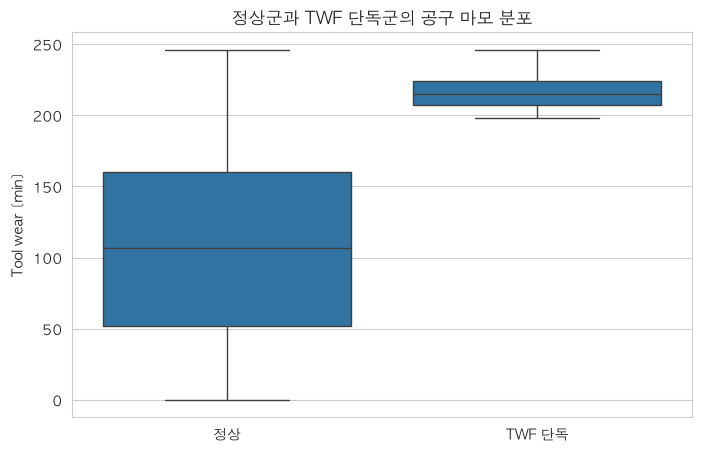

In [117]:
twf_compare = df_analysis.loc[
    normal_mask | twf_only_mask,
    [tool_wear_col, "TWF"]
].copy()

twf_compare["구분"] = twf_compare["TWF"].map({
    0: "정상",
    1: "TWF 단독",
})

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=twf_compare,
    x="구분",
    y=tool_wear_col,
)

plt.title("정상군과 TWF 단독군의 공구 마모 분포")
plt.xlabel("")
plt.ylabel("Tool wear [min]")
plt.show()

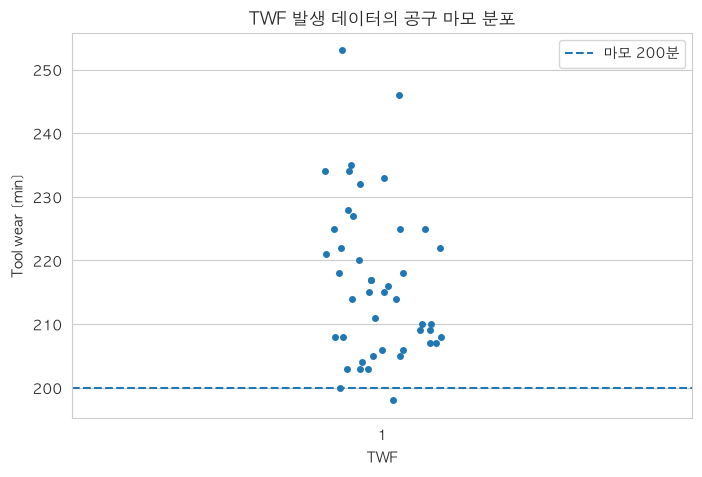

In [118]:
plt.figure(figsize=(8, 5))

sns.stripplot(
    data=df_analysis.loc[twf_mask],
    x="TWF",
    y=tool_wear_col,
    jitter=True,
)

plt.axhline(
    200,
    linestyle="--",
    label="마모 200분"
)

plt.title("TWF 발생 데이터의 공구 마모 분포")
plt.xlabel("TWF")
plt.ylabel("Tool wear [min]")
plt.legend()
plt.show()

In [119]:
twf_corr = df_analysis[
    [tool_wear_col, "TWF"]
].corr().loc[tool_wear_col, "TWF"]

print(
    "Tool wear와 TWF의 상관계수:",
    round(twf_corr, 4)
)

Tool wear와 TWF의 상관계수: 0.1149


In [120]:
type_twf_table = pd.crosstab(
    df_analysis["Type"],
    df_analysis["TWF"]
)

type_twf_table.columns = ["TWF 0", "TWF 1"]

type_twf_table["전체 건수"] = (
    type_twf_table["TWF 0"]
    + type_twf_table["TWF 1"]
)

type_twf_table["TWF 발생률(%)"] = (
    type_twf_table["TWF 1"]
    / type_twf_table["전체 건수"]
    * 100
)

display(type_twf_table.round(3))

,TWF 0,TWF 1,전체 건수,TWF 발생률(%)
Type,,,,
H,992,7,999,0.701
L,5963,24,5987,0.401
M,2981,14,2995,0.467


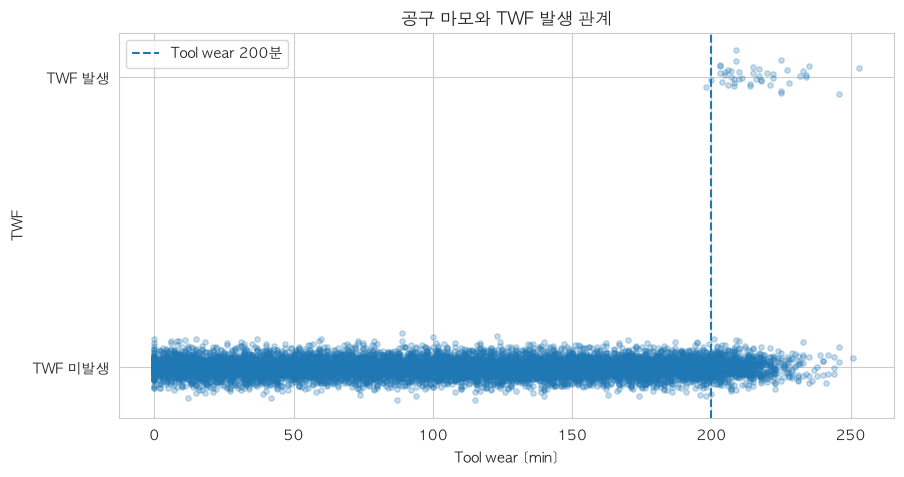

In [121]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# 점이 완전히 겹치지 않도록 y축에 작은 흔들림 추가
y_jitter = (
    df_analysis["TWF"]
    + np.random.normal(0, 0.03, len(df_analysis))
)

plt.scatter(
    df_analysis["Tool wear [min]"],
    y_jitter,
    alpha=0.25,
    s=15
)

plt.axvline(
    200,
    linestyle="--",
    label="Tool wear 200분"
)

plt.yticks([0, 1], ["TWF 미발생", "TWF 발생"])
plt.xlabel("Tool wear [min]")
plt.ylabel("TWF")
plt.title("공구 마모와 TWF 발생 관계")
plt.legend()
plt.show()

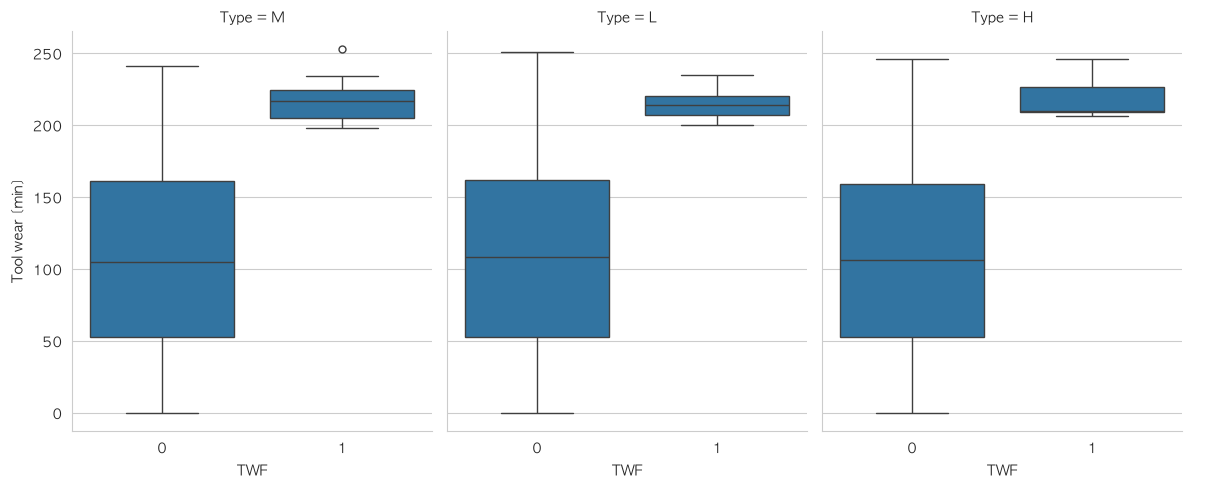

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=df_analysis,
    x="TWF",
    y="Tool wear [min]",
    col="Type",
    kind="box",
    height=5,
    aspect=0.8
)

plt.show()

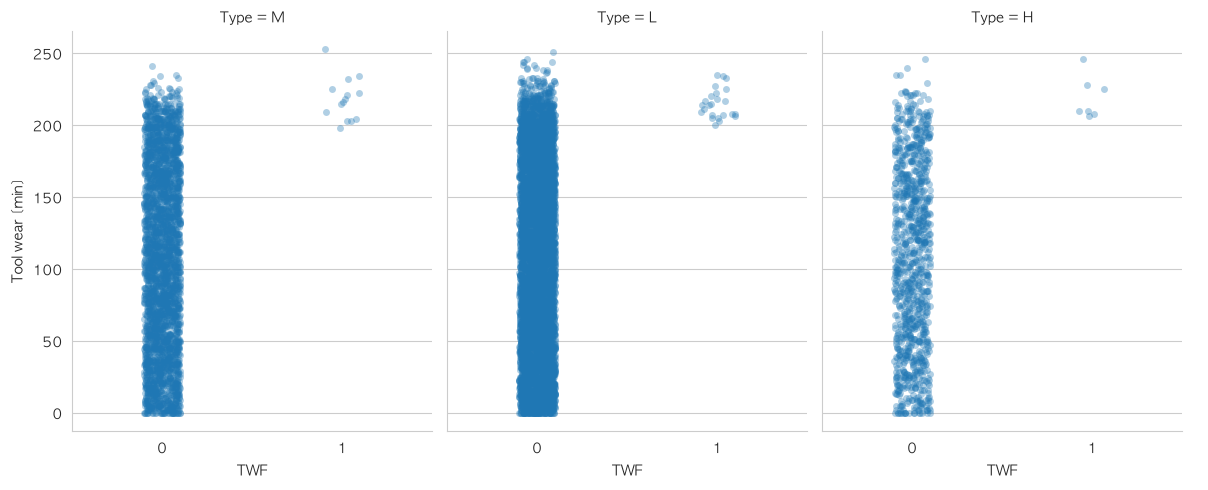

In [135]:
g = sns.catplot(
    data=df_analysis,
    x="TWF",
    y="Tool wear [min]",
    col="Type",
    kind="strip",
    jitter=True,
    alpha=0.35,
    height=5,
    aspect=0.8
)

g.set_axis_labels("TWF", "Tool wear [min]")
plt.show()

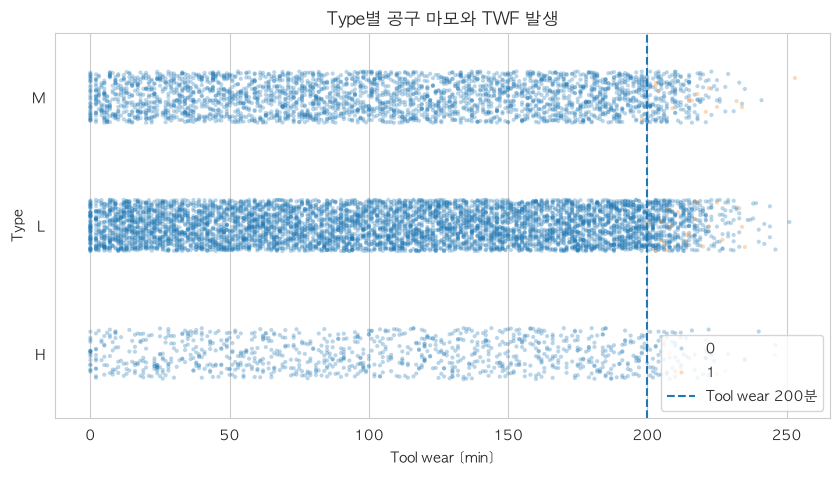

In [136]:
plt.figure(figsize=(10, 5))

sns.stripplot(
    data=df_analysis,
    x="Tool wear [min]",
    y="Type",
    hue="TWF",
    jitter=0.2,
    alpha=0.3,
    size=3
)

plt.axvline(200, linestyle="--", label="Tool wear 200분")
plt.title("Type별 공구 마모와 TWF 발생")
plt.legend()
plt.show()

In [137]:
wear_bins = [
    0, 100, 150, 180, 200,
    210, 220, 230, 240, 260
]

df_analysis["wear_group"] = pd.cut(
    df_analysis["Tool wear [min]"],
    bins=wear_bins,
    right=False
)

type_wear_twf = (
    df_analysis
    .groupby(
        ["Type", "wear_group"],
        observed=False
    )["TWF"]
    .agg(
        전체_건수="count",
        TWF_건수="sum",
        TWF_발생률="mean"
    )
    .reset_index()
)

type_wear_twf["TWF_발생률(%)"] = (
    type_wear_twf["TWF_발생률"] * 100
)

display(
    type_wear_twf[
        [
            "Type",
            "wear_group",
            "전체_건수",
            "TWF_건수",
            "TWF_발생률(%)"
        ]
    ].round(3)
)

,Type,wear_group,전체_건수,TWF_건수,TWF_발생률(%)
0,H,"[0, 100)",464,0,0.000
1,H,"[100, 150)",231,0,0.000
2,H,"[150, 180)",141,0,0.000
3,H,"[180, 200)",88,0,0.000
4,H,"[200, 210)",36,2,5.556
5,H,"[210, 220)",20,2,10.000
6,H,"[220, 230)",14,2,14.286
7,H,"[230, 240)",2,0,0.000
8,H,"[240, 260)",3,1,33.333
9,L,"[0, 100)",2751,0,0.000


In [151]:
plot_df = type_wear_twf.copy()

# 실제 데이터가 없는 빈 구간 제거
plot_df = plot_df[plot_df["전체_건수"] > 0].copy()

# Interval의 중간값을 숫자형 x축으로 사용
plot_df["wear_mid"] = (
    plot_df["wear_group"]
    .map(lambda interval: interval.mid)
    .astype(float)
)

# 눈금에 표시할 구간 문자열
plot_df["wear_label"] = plot_df["wear_group"].astype(str)

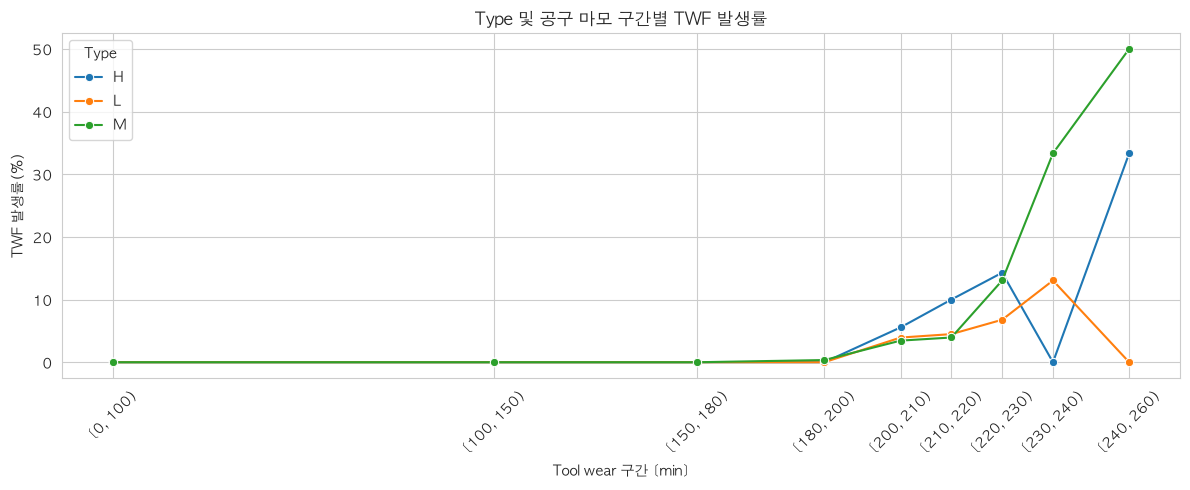

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=plot_df,
    x="wear_mid",
    y="TWF_발생률(%)",
    hue="Type",
    marker="o",
    sort=True
)

# 중간값 위치에 원래 구간 이름 표시
ticks = (
    plot_df[["wear_mid", "wear_label"]]
    .drop_duplicates()
    .sort_values("wear_mid")
)

plt.xticks(
    ticks["wear_mid"],
    ticks["wear_label"],
    rotation=45
)

plt.title("Type 및 공구 마모 구간별 TWF 발생률")
plt.xlabel("Tool wear 구간 [min]")
plt.ylabel("TWF 발생률(%)")
plt.tight_layout()
plt.show()

In [139]:
df_analysis["Temperature_difference"] = (
    df_analysis["Process temperature [K]"]
    - df_analysis["Air temperature [K]"]
)

In [140]:
target_cols = ["TWF", "HDF", "PWF", "OSF"]
other_hdf_targets = ["TWF", "PWF", "OSF"]

# 네 가지 고장이 모두 없는 정상 데이터
normal_mask = df_analysis[target_cols].sum(axis=1).eq(0)

# 다른 고장 동시 발생 여부와 관계없이 HDF가 발생한 데이터
hdf_mask = df_analysis["HDF"].eq(1)

# HDF만 단독으로 발생한 데이터
hdf_only_mask = (
    df_analysis["HDF"].eq(1)
    & df_analysis[other_hdf_targets].sum(axis=1).eq(0)
)

print("정상 데이터 수:", normal_mask.sum())
print("HDF 전체 데이터 수:", hdf_mask.sum())
print("HDF 단독 데이터 수:", hdf_only_mask.sum())

정상 데이터 수: 9652
HDF 전체 데이터 수: 115
HDF 단독 데이터 수: 106


In [141]:
hdf_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Temperature_difference",
    "Rotational speed [rpm]",
]

def summarize_group(mask):
    return df_analysis.loc[mask, hdf_features].agg(
        ["count", "mean", "median", "std", "min", "max"]
    ).T

normal_summary = summarize_group(normal_mask)
hdf_summary = summarize_group(hdf_only_mask)

print("정상군")
display(normal_summary.round(2))

print("HDF 단독군")
display(hdf_summary.round(2))

정상군


,count,mean,median,std,min,max
Air temperature [K],9652.0,299.97,300.0,1.99,295.3,304.5
Process temperature [K],9652.0,309.99,310.0,1.49,305.7,313.8
Temperature_difference,9652.0,10.02,9.8,0.99,7.6,12.1
Rotational speed [rpm],9652.0,1540.32,1507.0,167.44,1168.0,2695.0


HDF 단독군


,count,mean,median,std,min,max
Air temperature [K],106.0,302.56,302.4,0.60,300.8,303.7
Process temperature [K],106.0,310.80,310.7,0.63,309.4,312.2
Temperature_difference,106.0,8.24,8.3,0.28,7.6,8.6
Rotational speed [rpm],106.0,1340.71,1349.0,32.52,1212.0,1379.0


In [142]:
hdf_comparison = pd.DataFrame({
    "정상 평균": df_analysis.loc[normal_mask, hdf_features].mean(),
    "HDF 평균": df_analysis.loc[hdf_only_mask, hdf_features].mean(),
    "평균 차이(HDF-정상)": (
        df_analysis.loc[hdf_only_mask, hdf_features].mean()
        - df_analysis.loc[normal_mask, hdf_features].mean()
    ),
    "정상 중앙값": df_analysis.loc[normal_mask, hdf_features].median(),
    "HDF 중앙값": df_analysis.loc[hdf_only_mask, hdf_features].median(),
})

display(hdf_comparison.round(2))

,정상 평균,HDF 평균,평균 차이(HDF-정상),정상 중앙값,HDF 중앙값
Air temperature [K],299.97,302.56,2.59,300.0,302.4
Process temperature [K],309.99,310.80,0.81,310.0,310.7
Temperature_difference,10.02,8.24,-1.78,9.8,8.3
Rotational speed [rpm],1540.32,1340.71,-199.62,1507.0,1349.0


In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

hdf_compare = df_analysis.loc[
    normal_mask | hdf_only_mask,
    hdf_features + ["HDF"]
].copy()

hdf_compare["구분"] = hdf_compare["HDF"].map({
    0: "정상",
    1: "HDF 단독",
})

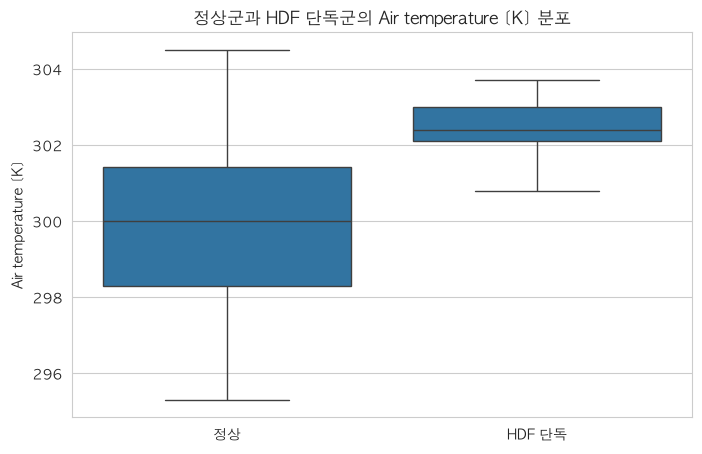

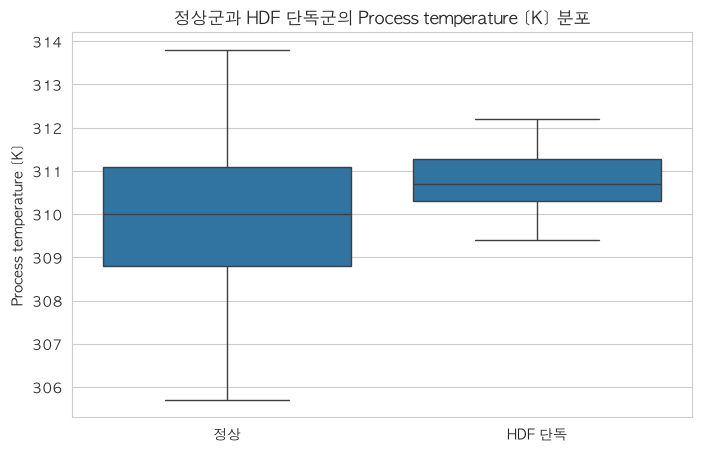

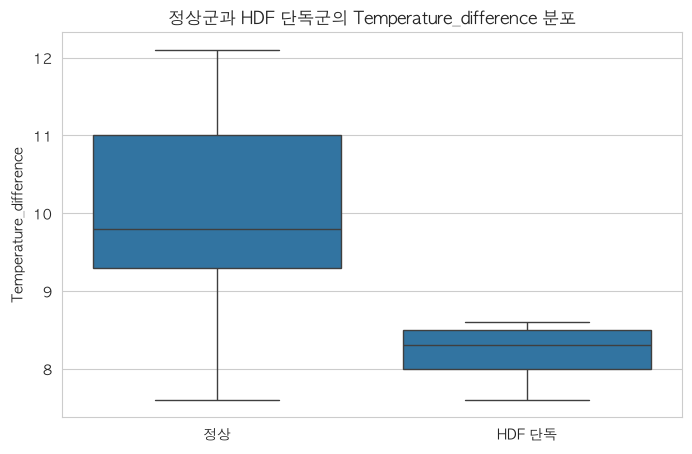

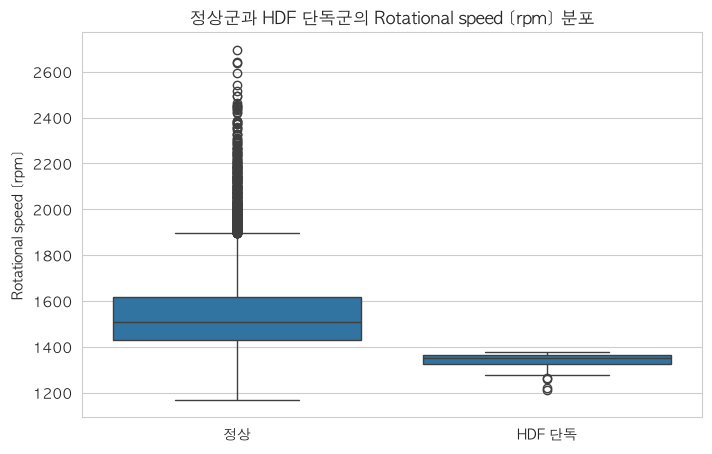

In [144]:
for feature in hdf_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=hdf_compare,
        x="구분",
        y=feature,
    )

    plt.title(f"정상군과 HDF 단독군의 {feature} 분포")
    plt.xlabel("")
    plt.ylabel(feature)
    plt.show()

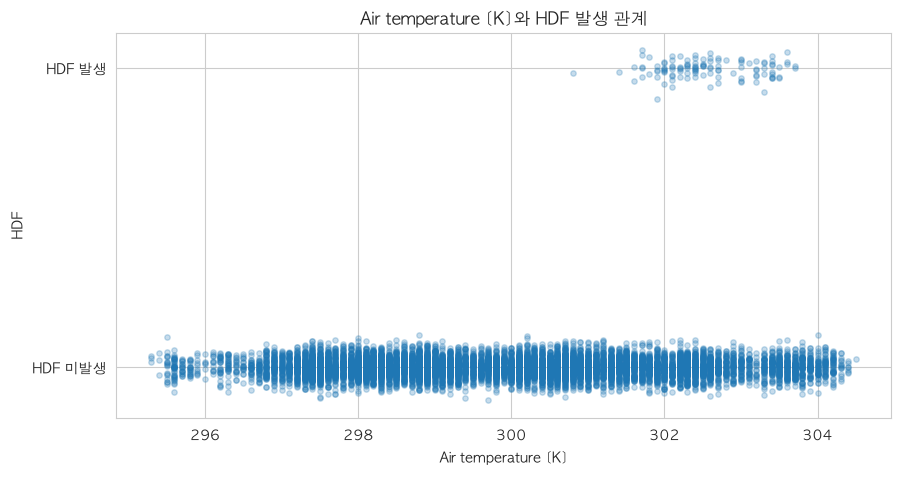

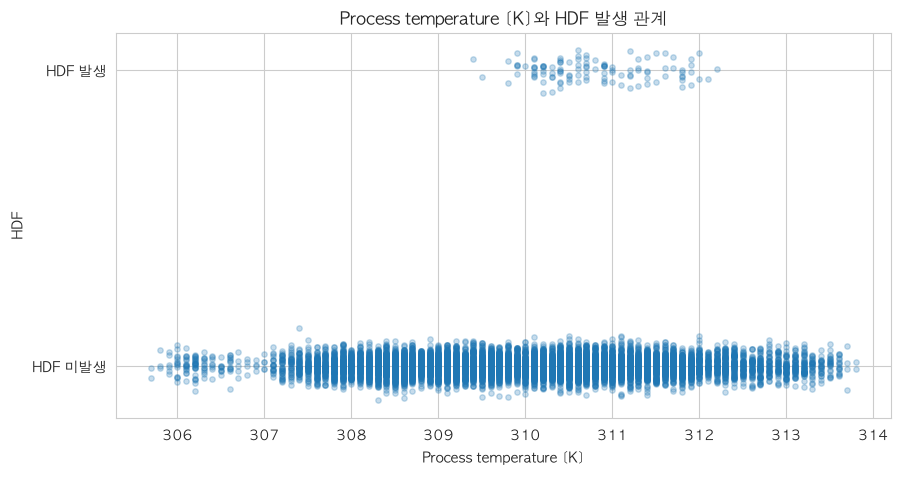

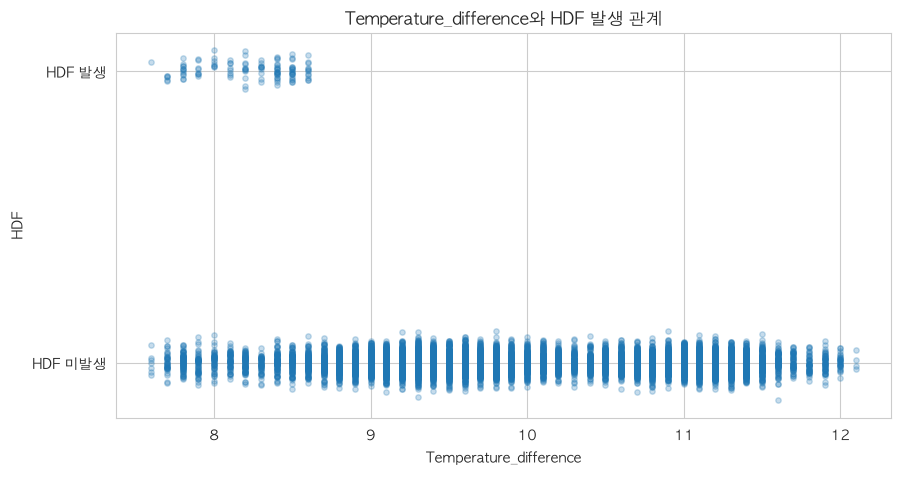

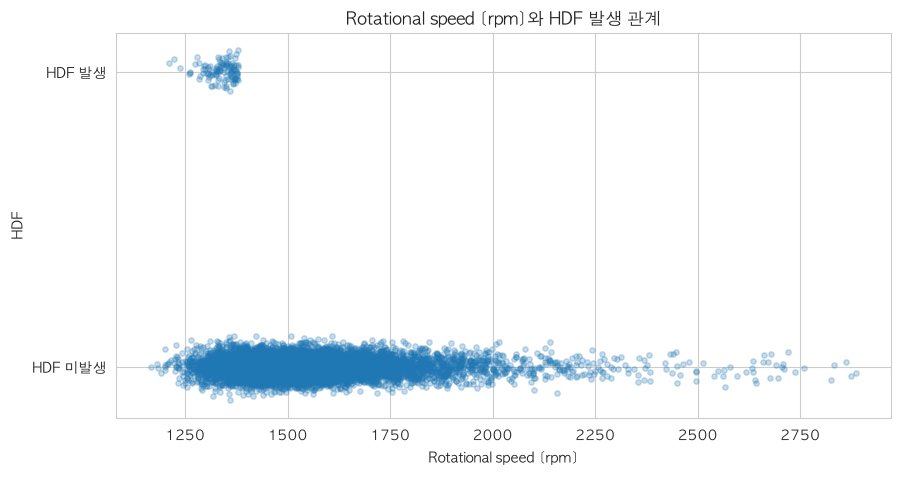

In [145]:
import numpy as np

for feature in hdf_features:
    plt.figure(figsize=(10, 5))

    y_jitter = (
        df_analysis["HDF"]
        + np.random.normal(0, 0.03, len(df_analysis))
    )

    plt.scatter(
        df_analysis[feature],
        y_jitter,
        alpha=0.25,
        s=15,
    )

    plt.yticks([0, 1], ["HDF 미발생", "HDF 발생"])
    plt.xlabel(feature)
    plt.ylabel("HDF")
    plt.title(f"{feature}와 HDF 발생 관계")
    plt.show()

In [146]:
hdf_corr = (
    df_analysis[hdf_features + ["HDF"]]
    .corr()
    ["HDF"]
    .drop("HDF")
    .sort_values()
)

display(hdf_corr.to_frame("HDF와 상관계수").round(4))

,HDF와 상관계수
Temperature_difference,-0.1911
Rotational speed [rpm],-0.1214
Process temperature [K],0.0571
Air temperature [K],0.1380


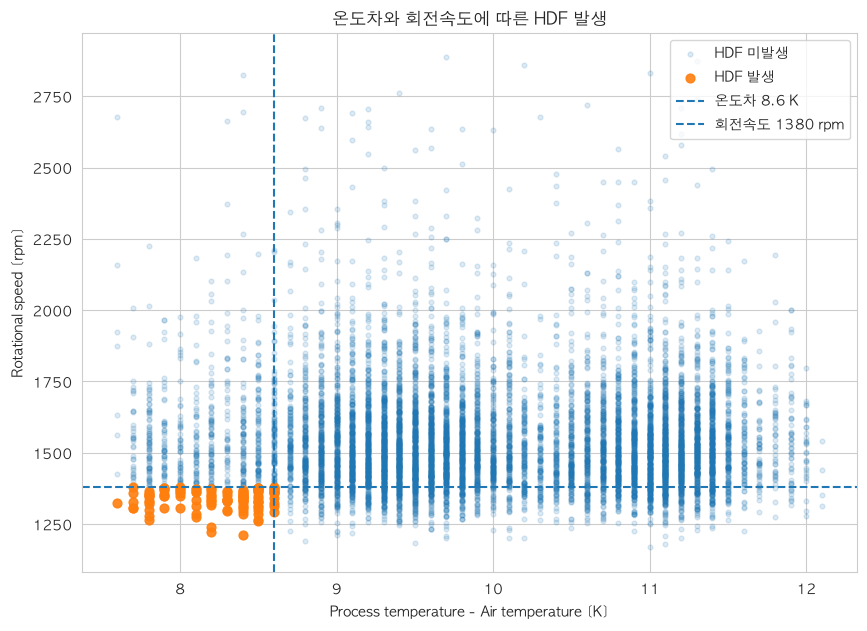

In [147]:
hdf_0 = df_analysis[df_analysis["HDF"] == 0]
hdf_1 = df_analysis[df_analysis["HDF"] == 1]

plt.figure(figsize=(10, 7))

# HDF 미발생을 먼저 그림
plt.scatter(
    hdf_0["Temperature_difference"],
    hdf_0["Rotational speed [rpm]"],
    alpha=0.15,
    s=12,
    label="HDF 미발생",
)

# HDF 발생을 위에 그림
plt.scatter(
    hdf_1["Temperature_difference"],
    hdf_1["Rotational speed [rpm]"],
    alpha=0.9,
    s=40,
    label="HDF 발생",
)

plt.axvline(
    8.6,
    linestyle="--",
    label="온도차 8.6 K",
)

plt.axhline(
    1380,
    linestyle="--",
    label="회전속도 1380 rpm",
)

plt.xlabel("Process temperature - Air temperature [K]")
plt.ylabel("Rotational speed [rpm]")
plt.title("온도차와 회전속도에 따른 HDF 발생")
plt.legend()
plt.show()

In [148]:
hdf_condition = (
    (df_analysis["Temperature_difference"] < 8.6)
    & (df_analysis["Rotational speed [rpm]"] < 1380)
)

condition_check = pd.crosstab(
    hdf_condition,
    df_analysis["HDF"],
    rownames=["HDF 조건 충족"],
    colnames=["실제 HDF"],
)

display(condition_check)

실제 HDF,0,1
HDF 조건 충족,,
False,9866,0
True,0,115


In [149]:
hdf_rule_match = (
    hdf_condition.astype(int)
    == df_analysis["HDF"]
).mean()

print(
    "HDF 조건과 실제 라벨 일치율:",
    round(hdf_rule_match * 100, 2),
    "%"
)

HDF 조건과 실제 라벨 일치율: 100.0 %


In [153]:
df_analysis["Strain"] = (
    df_analysis["Tool wear [min]"]
    * df_analysis["Torque [Nm]"]
)

In [154]:
strain_limits = {
    "L": 11000,
    "M": 12000,
    "H": 13000,
}

df_analysis["Strain_limit"] = (
    df_analysis["Type"].map(strain_limits)
)

In [155]:
df_analysis["Strain_ratio"] = (
    df_analysis["Strain"]
    / df_analysis["Strain_limit"]
)

In [156]:
target_cols = ["TWF", "HDF", "PWF", "OSF"]
other_osf_targets = ["TWF", "HDF", "PWF"]

# 네 가지 고장이 모두 발생하지 않은 행
normal_mask = (
    df_analysis[target_cols]
    .sum(axis=1)
    .eq(0)
)

# 다른 고장 동시 발생 여부와 관계없이 OSF가 발생한 행
osf_mask = df_analysis["OSF"].eq(1)

# OSF만 단독으로 발생한 행
osf_only_mask = (
    df_analysis["OSF"].eq(1)
    & df_analysis[other_osf_targets].sum(axis=1).eq(0)
)

print("정상 데이터 수:", normal_mask.sum())
print("OSF 전체 데이터 수:", osf_mask.sum())
print("OSF 단독 데이터 수:", osf_only_mask.sum())

정상 데이터 수: 9652
OSF 전체 데이터 수: 98
OSF 단독 데이터 수: 78


In [157]:
osf_features = [
    "Tool wear [min]",
    "Torque [Nm]",
    "Strain",
    "Strain_ratio",
]

def summarize_osf(mask):
    return (
        df_analysis.loc[mask, osf_features]
        .agg([
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ])
        .T
    )

print("정상군")
display(summarize_osf(normal_mask).round(2))

print("OSF 단독군")
display(summarize_osf(osf_only_mask).round(2))

정상군


,count,mean,median,std,min,max
Tool wear [min],9652.0,106.68,107.00,62.93,0.0,246.0
Torque [Nm],9652.0,39.62,39.90,9.47,12.6,70.0
Strain,9652.0,4212.59,3952.20,2708.73,0.0,11919.8
Strain_ratio,9652.0,0.37,0.35,0.24,0.0,1.0


OSF 단독군


,count,mean,median,std,min,max
Tool wear [min],78.0,208.22,207.00,14.45,177.0,251.00
Torque [Nm],78.0,56.88,56.75,4.90,46.3,68.20
Strain,78.0,11794.24,11545.40,743.63,11003.2,14040.00
Strain_ratio,78.0,1.06,1.05,0.06,1.0,1.28


In [158]:
osf_comparison = pd.DataFrame({
    "정상 평균": (
        df_analysis.loc[normal_mask, osf_features].mean()
    ),
    "OSF 평균": (
        df_analysis.loc[osf_only_mask, osf_features].mean()
    ),
    "평균 차이": (
        df_analysis.loc[osf_only_mask, osf_features].mean()
        - df_analysis.loc[normal_mask, osf_features].mean()
    ),
    "정상 중앙값": (
        df_analysis.loc[normal_mask, osf_features].median()
    ),
    "OSF 중앙값": (
        df_analysis.loc[osf_only_mask, osf_features].median()
    ),
})

display(osf_comparison.round(2))

,정상 평균,OSF 평균,평균 차이,정상 중앙값,OSF 중앙값
Tool wear [min],106.68,208.22,101.54,107.00,207.00
Torque [Nm],39.62,56.88,17.25,39.90,56.75
Strain,4212.59,11794.24,7581.65,3952.20,11545.40
Strain_ratio,0.37,1.06,0.70,0.35,1.05


In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

osf_compare = df_analysis.loc[
    normal_mask | osf_only_mask,
    osf_features + ["OSF"]
].copy()

osf_compare["구분"] = osf_compare["OSF"].map({
    0: "정상",
    1: "OSF 단독",
})

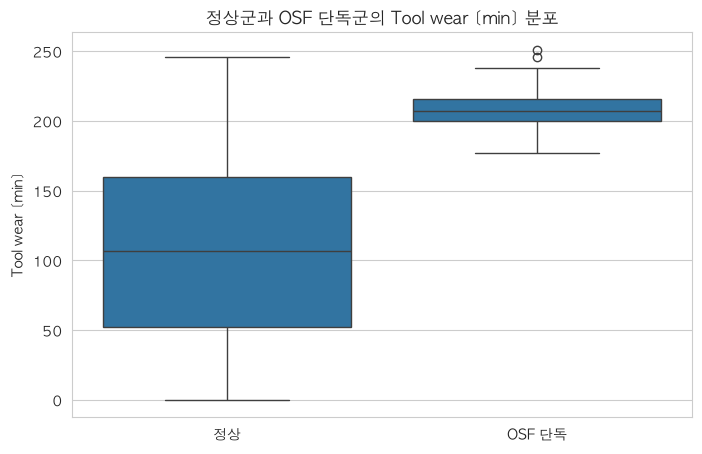

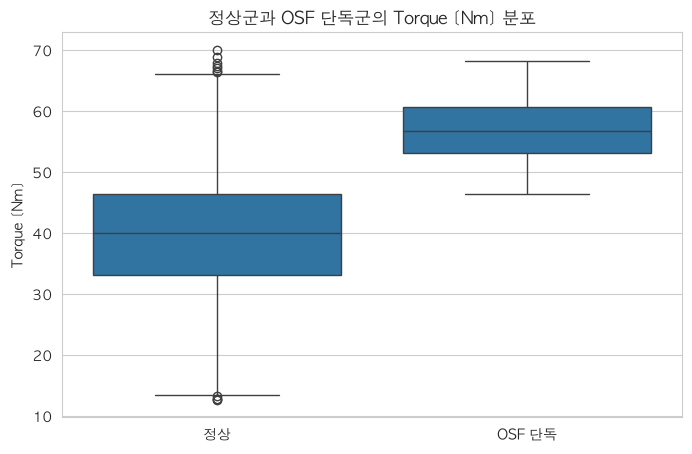

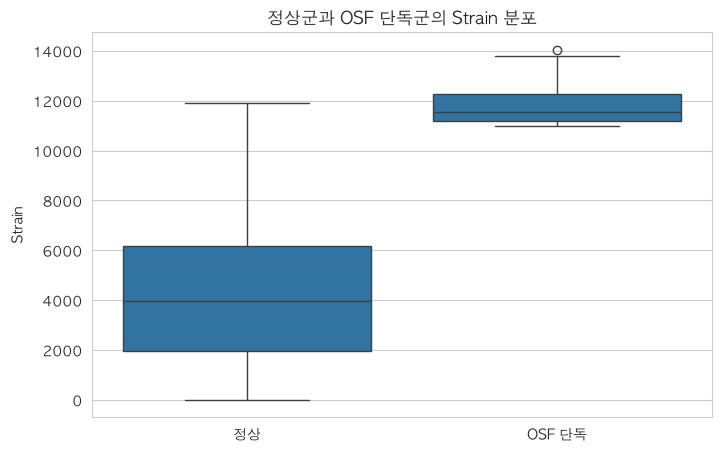

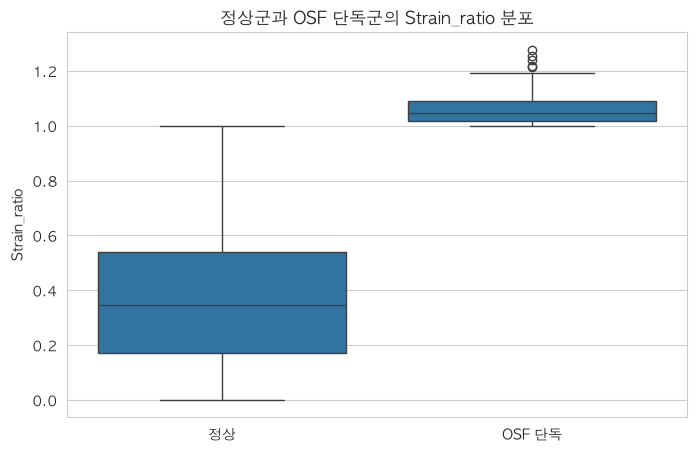

In [160]:
for feature in osf_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=osf_compare,
        x="구분",
        y=feature,
    )

    plt.title(f"정상군과 OSF 단독군의 {feature} 분포")
    plt.xlabel("")
    plt.ylabel(feature)
    plt.show()

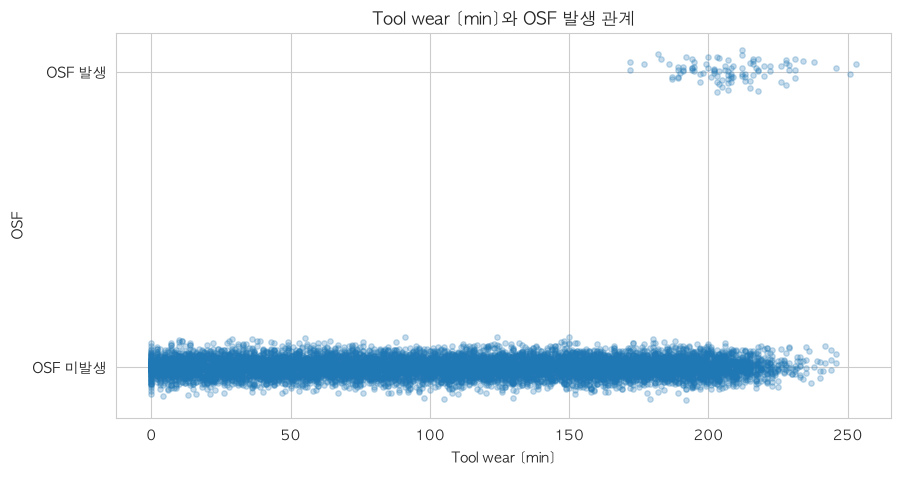

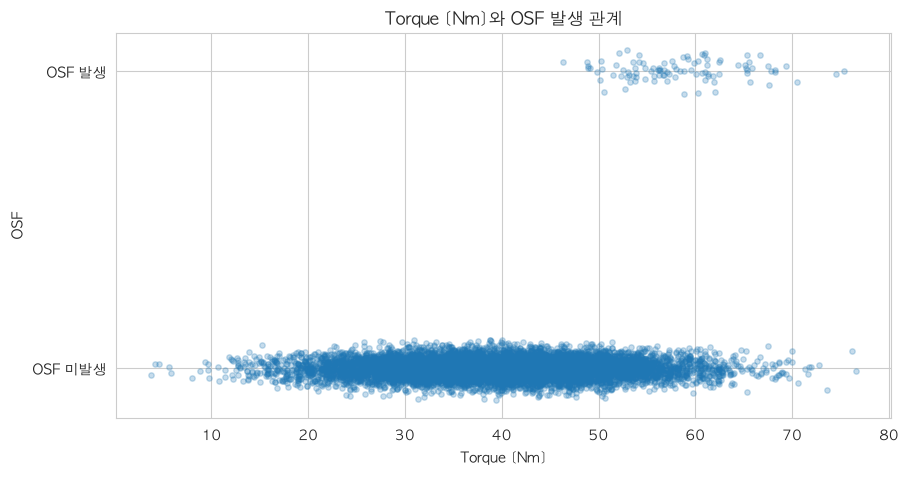

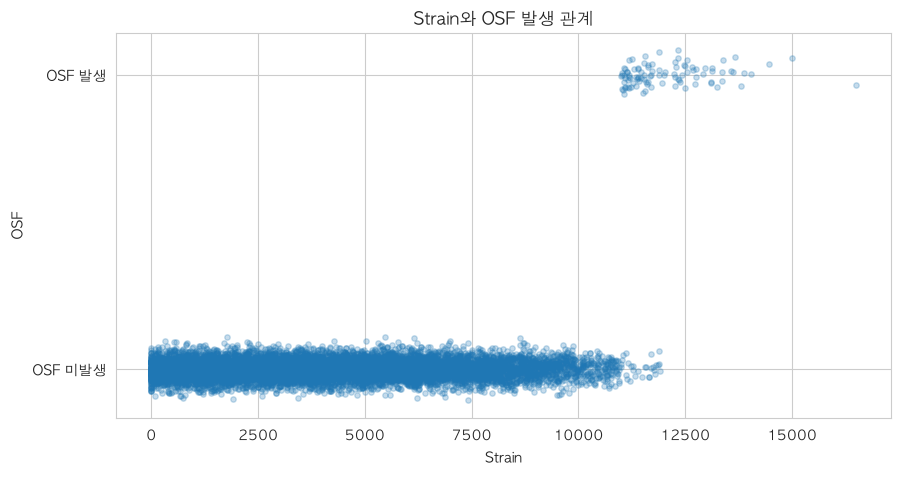

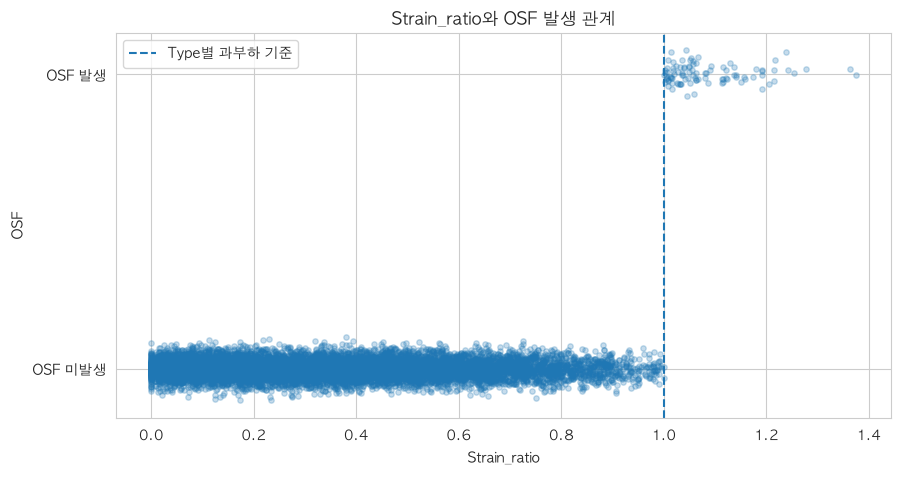

In [161]:
import numpy as np

for feature in osf_features:
    plt.figure(figsize=(10, 5))

    y_jitter = (
        df_analysis["OSF"]
        + np.random.normal(
            0,
            0.03,
            len(df_analysis)
        )
    )

    plt.scatter(
        df_analysis[feature],
        y_jitter,
        alpha=0.25,
        s=15,
    )

    if feature == "Strain_ratio":
        plt.axvline(
            1,
            linestyle="--",
            label="Type별 과부하 기준",
        )
        plt.legend()

    plt.yticks(
        [0, 1],
        ["OSF 미발생", "OSF 발생"],
    )

    plt.xlabel(feature)
    plt.ylabel("OSF")
    plt.title(f"{feature}와 OSF 발생 관계")
    plt.show()

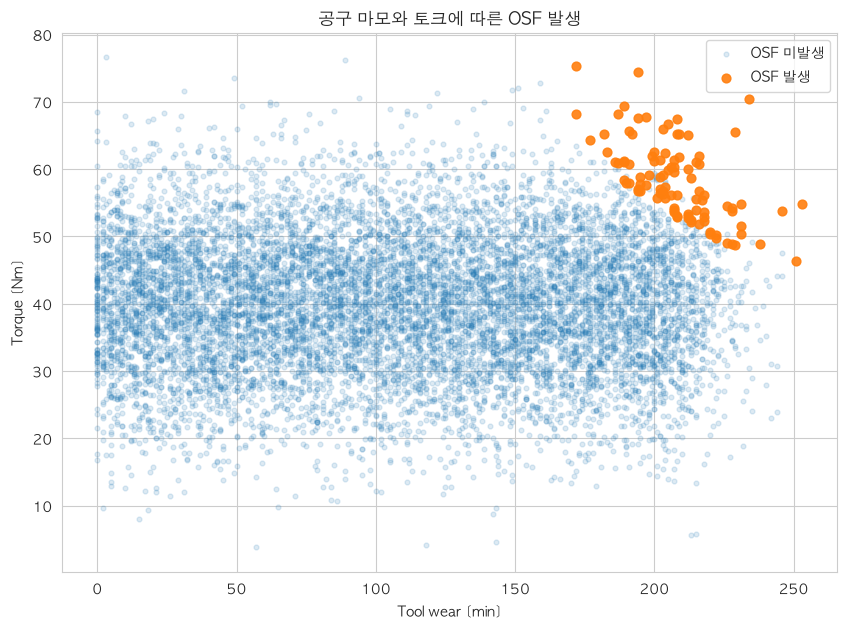

In [162]:
osf_0 = df_analysis[df_analysis["OSF"] == 0]
osf_1 = df_analysis[df_analysis["OSF"] == 1]

plt.figure(figsize=(10, 7))

plt.scatter(
    osf_0["Tool wear [min]"],
    osf_0["Torque [Nm]"],
    alpha=0.15,
    s=12,
    label="OSF 미발생",
)

plt.scatter(
    osf_1["Tool wear [min]"],
    osf_1["Torque [Nm]"],
    alpha=0.9,
    s=40,
    label="OSF 발생",
)

plt.xlabel("Tool wear [min]")
plt.ylabel("Torque [Nm]")
plt.title("공구 마모와 토크에 따른 OSF 발생")
plt.legend()
plt.show()

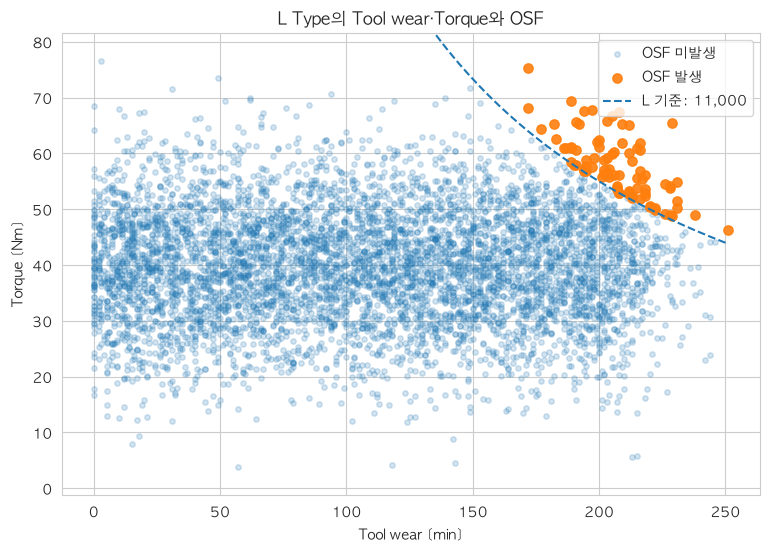

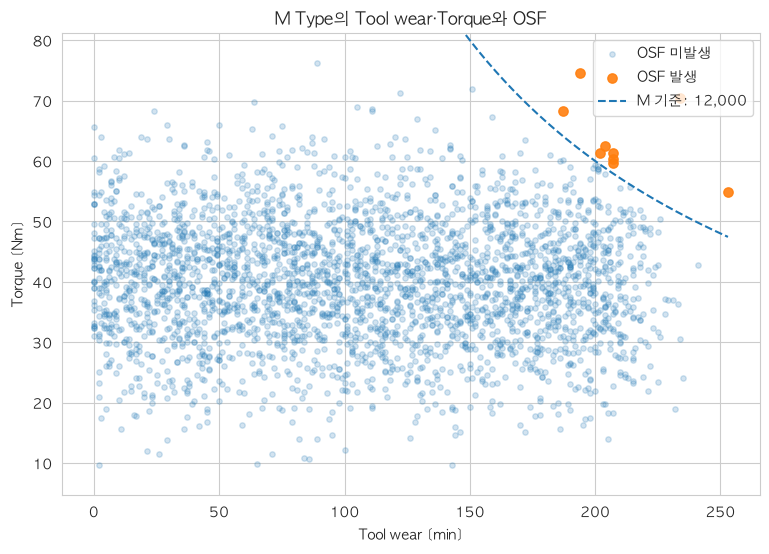

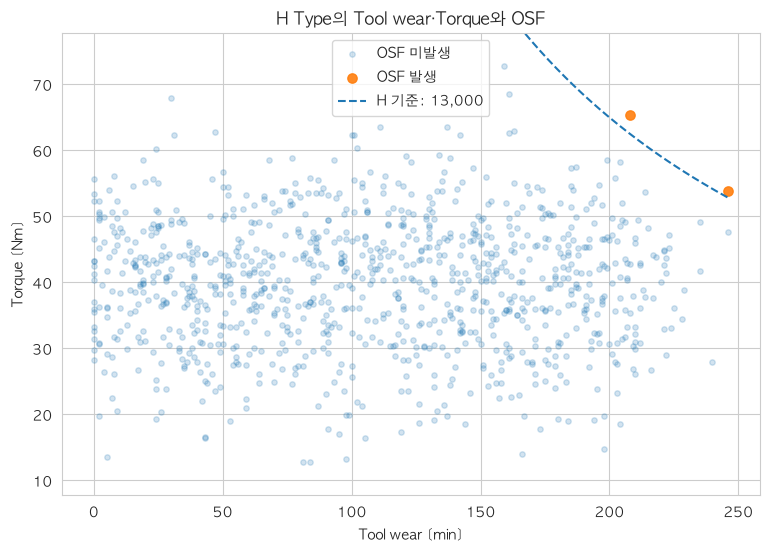

In [163]:
import numpy as np

for machine_type, limit in strain_limits.items():
    type_df = df_analysis[
        df_analysis["Type"] == machine_type
    ]

    osf_0 = type_df[type_df["OSF"] == 0]
    osf_1 = type_df[type_df["OSF"] == 1]

    plt.figure(figsize=(9, 6))

    plt.scatter(
        osf_0["Tool wear [min]"],
        osf_0["Torque [Nm]"],
        alpha=0.2,
        s=15,
        label="OSF 미발생",
    )

    plt.scatter(
        osf_1["Tool wear [min]"],
        osf_1["Torque [Nm]"],
        alpha=0.9,
        s=45,
        label="OSF 발생",
    )

    # Strain = Tool wear × Torque = limit
    wear_range = np.linspace(
        1,
        type_df["Tool wear [min]"].max(),
        300,
    )

    torque_boundary = limit / wear_range

    plt.plot(
        wear_range,
        torque_boundary,
        linestyle="--",
        label=f"{machine_type} 기준: {limit:,}",
    )

    plt.ylim(
        type_df["Torque [Nm]"].min() - 5,
        type_df["Torque [Nm]"].max() + 5,
    )

    plt.xlabel("Tool wear [min]")
    plt.ylabel("Torque [Nm]")
    plt.title(
        f"{machine_type} Type의 Tool wear·Torque와 OSF"
    )
    plt.legend()
    plt.show()

In [164]:
osf_corr = (
    df_analysis[
        osf_features + ["OSF"]
    ]
    .corr()
    ["OSF"]
    .drop("OSF")
    .sort_values(ascending=False)
)

display(
    osf_corr
    .to_frame("OSF와 상관계수")
    .round(4)
)

,OSF와 상관계수
Strain_ratio,0.2838
Strain,0.2733
Torque [Nm],0.1837
Tool wear [min],0.1561


In [165]:
type_osf = (
    df_analysis
    .groupby("Type")["OSF"]
    .agg(
        전체_건수="count",
        OSF_건수="sum",
        OSF_발생률="mean",
    )
)

type_osf["OSF_발생률(%)"] = (
    type_osf["OSF_발생률"] * 100
)

display(type_osf.round(3))

,전체_건수,OSF_건수,OSF_발생률,OSF_발생률(%)
Type,,,,
H,999,2,0.002,0.200
L,5987,87,0.015,1.453
M,2995,9,0.003,0.301
